# Day 18 - Seaborn Basics (Part 1)

---

**Author:** Shaurab Kumar Jha  
**Date:** Day 18 of 90  
**Goal:** MNC-ready Python & Gen AI Engineer

**What you will learn today:**
- Why Seaborn exists and how it sits on top of Matplotlib
- Figure-level vs Axis-level functions - the most important concept in Seaborn
- Faceting: splitting one chart into many automatically using col= and row=
- Scatter plot with hue, style, size encoding
- Line plot with grouping
- Histogram with hue and element types
- KDE plot - what it is and when to use it
- Rug plot - showing individual data points along an axis
- Bivariate plots - 2D histogram and 2D KDE
- Heatmap with pivot table
- Clustermap with hierarchical clustering

---

**Dataset today:** `sns.load_dataset('tips')` - restaurant tips data. 244 rows, mix of numerical and categorical columns. Perfect for demonstrating every Seaborn feature.

---

# Part 1: Why Seaborn? Matplotlib vs Seaborn

## The Core Problem with Matplotlib

Matplotlib is powerful but verbose. To do something simple like coloring scatter points by a categorical column, you need to:
1. Find all unique categories
2. Create a color map
3. Loop through categories
4. Plot each group separately with a label
5. Add a legend manually

That is 10-15 lines of code for something you want to do in every exploratory chart.

With Seaborn, you write:
```python
sns.scatterplot(data=df, x='total_bill', y='tip', hue='sex')
```

One line. Done. Seaborn handles the grouping, coloring, and legend automatically.

---

## What Seaborn Actually Is

Seaborn is NOT a replacement for Matplotlib. It is a high-level wrapper built on top of Matplotlib.

Every Seaborn chart is ultimately a Matplotlib figure. When Seaborn finishes drawing, you can still use plt.title(), plt.savefig(), ax.set_xlabel() etc to customize further.

Think of it this way:
- Matplotlib = the engine
- Seaborn = the luxury car body built on that engine

You get a beautiful driving experience, but the engine is still Matplotlib underneath.

---

## Key Advantages of Seaborn

**1. hue parameter** - automatically groups data by a categorical column and assigns different colors. This single parameter replaces 15 lines of Matplotlib loop code.

**2. Direct DataFrame support** - you pass `data=df` and then just write column names as strings. No need to extract df['column'] manually.

**3. Statistical plots built-in** - KDE, confidence intervals, regression lines, violin plots. Matplotlib has none of these natively.

**4. Beautiful defaults** - Seaborn themes look professional out of the box. No style.use() needed.

**5. Faceting** - split one chart into a grid of charts by a category, in one line of code.

---

## When to Use Matplotlib Directly vs Seaborn

Use Seaborn when:
- Your data is in a DataFrame
- You want to explore relationships between columns
- You need statistical visualizations (KDE, violin, confidence bands)
- You want grouped/colored charts quickly

Use Matplotlib directly when:
- You need precise control over every pixel
- You are doing custom artistic charts
- You are working with arrays, not DataFrames
- You need chart types that Seaborn does not have (3D, surface plots)

---

# Part 2: Figure-level vs Axis-level Functions

## This is the Most Confusing Part of Seaborn for Beginners

Seaborn has two types of functions and they behave differently. If you do not understand this, your code will break in confusing ways.

---

## Axis-level Functions

These draw on a specific Matplotlib axes object. They behave like Matplotlib functions.

Examples:
- `sns.scatterplot()`
- `sns.lineplot()`
- `sns.histplot()`
- `sns.kdeplot()`
- `sns.boxplot()`
- `sns.violinplot()`
- `sns.barplot()`

Characteristics:
- Return a Matplotlib `axes` object
- You can use them inside `plt.subplots()` grids
- Controlled with `ax=` parameter: `sns.scatterplot(..., ax=axes[0,1])`
- figsize is controlled outside via `plt.figure(figsize=...)`

---

## Figure-level Functions

These create their OWN figure and manage their own layout. They are wrappers around axis-level functions.

Examples:
- `sns.relplot()` - wraps scatterplot and lineplot
- `sns.displot()` - wraps histplot, kdeplot, ecdfplot
- `sns.catplot()` - wraps boxplot, violinplot, barplot, stripplot, etc.

Characteristics:
- Return a `FacetGrid` object (not an axes object)
- Create their own figure - do NOT use inside plt.subplots()
- Size is controlled by `height=` and `aspect=` parameters (not figsize)
- The real power: they support `col=` and `row=` for faceting

---

## The Rule

```
One chart in a specific location  ->  use axis-level (scatterplot, histplot, etc.)
Automatic faceted grid of charts  ->  use figure-level (relplot, displot, catplot)
```

The `kind=` parameter of figure-level functions selects which axis-level function to use:
- `sns.relplot(kind='scatter')` uses scatterplot internally
- `sns.relplot(kind='line')` uses lineplot internally
- `sns.displot(kind='hist')` uses histplot internally
- `sns.displot(kind='kde')` uses kdeplot internally

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

os.makedirs('day18_charts', exist_ok=True)

# Set Seaborn theme
# style options: 'darkgrid', 'whitegrid', 'dark', 'white', 'ticks'
# palette options: 'deep', 'muted', 'bright', 'pastel', 'dark', 'colorblind'
# font_scale scales all text sizes
sns.set_theme(style='whitegrid', palette='deep', font_scale=1.1)

# Load the tips dataset
# This is built into Seaborn - no file needed
tips = sns.load_dataset('tips')

print('Tips dataset loaded successfully')
print(f'Shape: {tips.shape}')
print()
print('First 5 rows:')
print(tips.head())
print()
print('Column info:')
print(tips.dtypes)
print()
print('Summary statistics:')
print(tips.describe())

Tips dataset loaded successfully
Shape: (244, 7)

First 5 rows:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Column info:
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Summary statistics:
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


In [2]:
# Understanding the Tips dataset before we plot anything
# Always understand your data BEFORE visualizing it

print('Unique values in categorical columns:')
print()
print('sex     :', tips['sex'].unique())
print('smoker  :', tips['smoker'].unique())
print('day     :', tips['day'].unique())
print('time    :', tips['time'].unique())
print()
print('Count by day:')
print(tips['day'].value_counts())
print()
print('Count by time:')
print(tips['time'].value_counts())
print()
print('Average tip by sex:')
print(tips.groupby('sex')['tip'].mean())

Unique values in categorical columns:

sex     : ['Female', 'Male']
Categories (2, object): ['Male', 'Female']
smoker  : ['No', 'Yes']
Categories (2, object): ['Yes', 'No']
day     : ['Sun', 'Sat', 'Thur', 'Fri']
Categories (4, object): ['Thur', 'Fri', 'Sat', 'Sun']
time    : ['Dinner', 'Lunch']
Categories (2, object): ['Lunch', 'Dinner']

Count by day:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

Count by time:
time
Dinner    176
Lunch      68
Name: count, dtype: int64

Average tip by sex:
sex
Male      3.089618
Female    2.833448
Name: tip, dtype: float64


/tmp/ipykernel_6567/217968628.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(tips.groupby('sex')['tip'].mean())


### Understanding the Tips Dataset

Before plotting, always know what your columns mean:

- `total_bill` - total restaurant bill in USD (numerical, continuous)
- `tip` - tip amount in USD (numerical, continuous)
- `sex` - customer gender: Male/Female (categorical, 2 categories)
- `smoker` - smoker or not: Yes/No (categorical, 2 categories)
- `day` - day of week: Thur/Fri/Sat/Sun (categorical, 4 categories)
- `time` - Lunch or Dinner (categorical, 2 categories)
- `size` - number of people at the table: 1-6 (numerical, but discrete)

This dataset has a perfect mix: 2 numerical + 4 categorical columns. Great for demonstrating hue, style, size encoding.

---

# Part 3: Scatter Plot - hue, style, size Encoding

## The Concept of Visual Encoding

A scatter plot has two visual channels by default: x-position and y-position. That is 2 variables.

Seaborn lets you encode additional variables using:
- `hue=` - maps a variable to COLOR of each point
- `style=` - maps a variable to the SHAPE of each point (circle, square, triangle, etc.)
- `size=` - maps a variable to the SIZE of each point

Now one scatter plot can show 5 variables simultaneously:
- x-position = total_bill
- y-position = tip
- color = sex
- shape = smoker
- size = size (number of people)

In Matplotlib, encoding even one extra variable takes 15+ lines. In Seaborn, you add one parameter.

---

## hue_norm and sizes Parameters

When you use `size=` with a numerical column:
- `sizes=(min_size, max_size)` - controls the range of dot sizes. Without this, the difference between sizes might be too small or too large.

When you use `hue=` with a numerical column:
- `palette='viridis'` - use a sequential colormap (low value = one color, high = another)

When you use `hue=` with a categorical column:
- `palette='deep'` or `palette=['red', 'blue']` - use qualitative colors (different colors for different categories, no implied order)

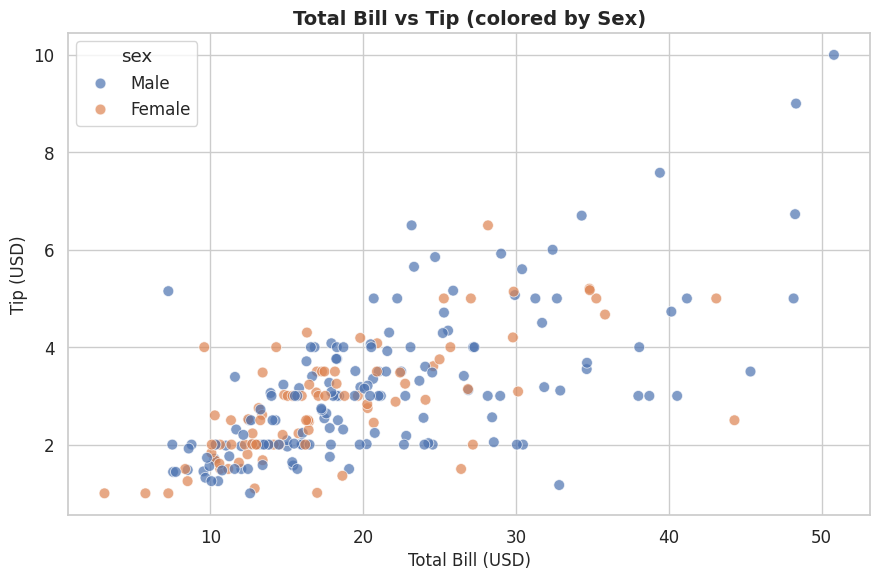

Basic hue scatter saved!


In [3]:
# --- SCATTER 1: Basic scatter with just hue ---
fig, ax = plt.subplots(figsize=(9, 6))

# hue='sex' colors each dot by sex (Male=one color, Female=another)
# Seaborn automatically:
#   - finds unique values of 'sex'
#   - assigns a different color to each
#   - draws all Male points
#   - draws all Female points
#   - creates a legend with those labels
# In Matplotlib all of this would be a for loop + manual colors + manual legend

sns.scatterplot(
    data=tips,
    x='total_bill',
    y='tip',
    hue='sex',          # color by sex
    alpha=0.7,
    s=60,               # dot size (uniform since we are not using size=)
    ax=ax
)

ax.set_title('Total Bill vs Tip (colored by Sex)', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Bill (USD)', fontsize=12)
ax.set_ylabel('Tip (USD)', fontsize=12)

plt.tight_layout()
plt.savefig('day18_charts/1a_scatter_hue.png', dpi=150, bbox_inches='tight')
plt.show()
print('Basic hue scatter saved!')

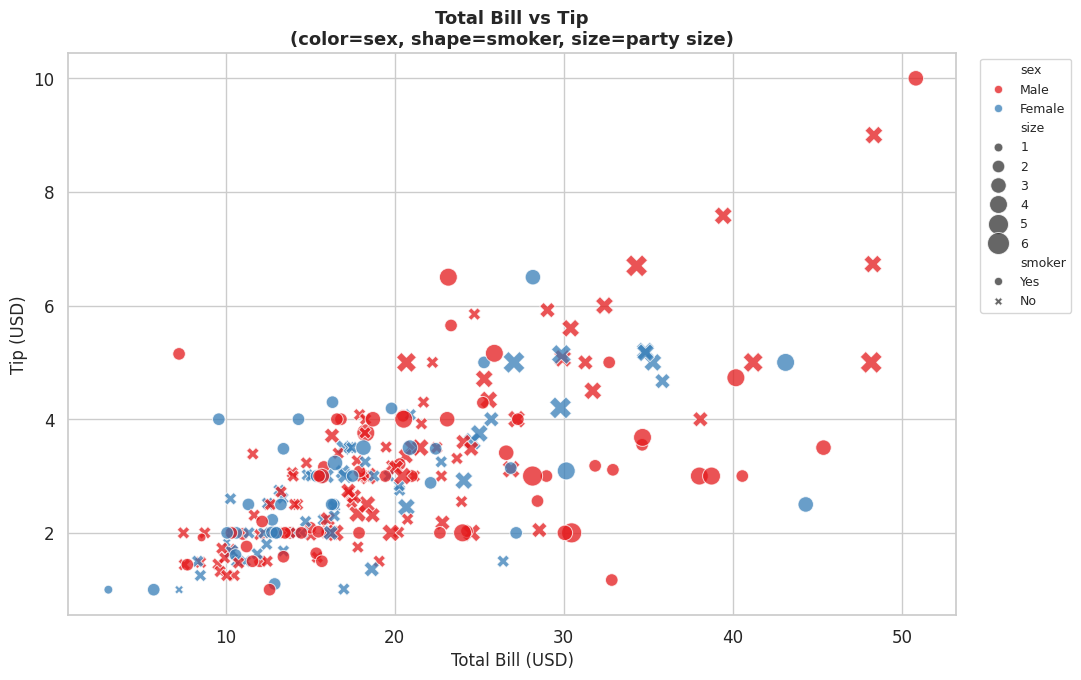

Full encoding scatter saved!


In [4]:
# --- SCATTER 2: hue + style + size (full encoding) ---
fig, ax = plt.subplots(figsize=(11, 7))

sns.scatterplot(
    data=tips,
    x='total_bill',
    y='tip',
    hue='sex',           # color = sex
    style='smoker',      # shape = smoker status (o for No, X for Yes)
    size='size',         # dot size = number of people at table
    sizes=(40, 250),     # map 'size' column range to dot size range 40-250px
    alpha=0.75,
    palette='Set1',
    ax=ax
)

ax.set_title('Total Bill vs Tip\n(color=sex, shape=smoker, size=party size)', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Bill (USD)', fontsize=12)
ax.set_ylabel('Tip (USD)', fontsize=12)

# Legend is automatically created by Seaborn with sections for each encoded variable
# You can move it
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('day18_charts/1b_scatter_hue_style_size.png', dpi=150, bbox_inches='tight')
plt.show()
print('Full encoding scatter saved!')

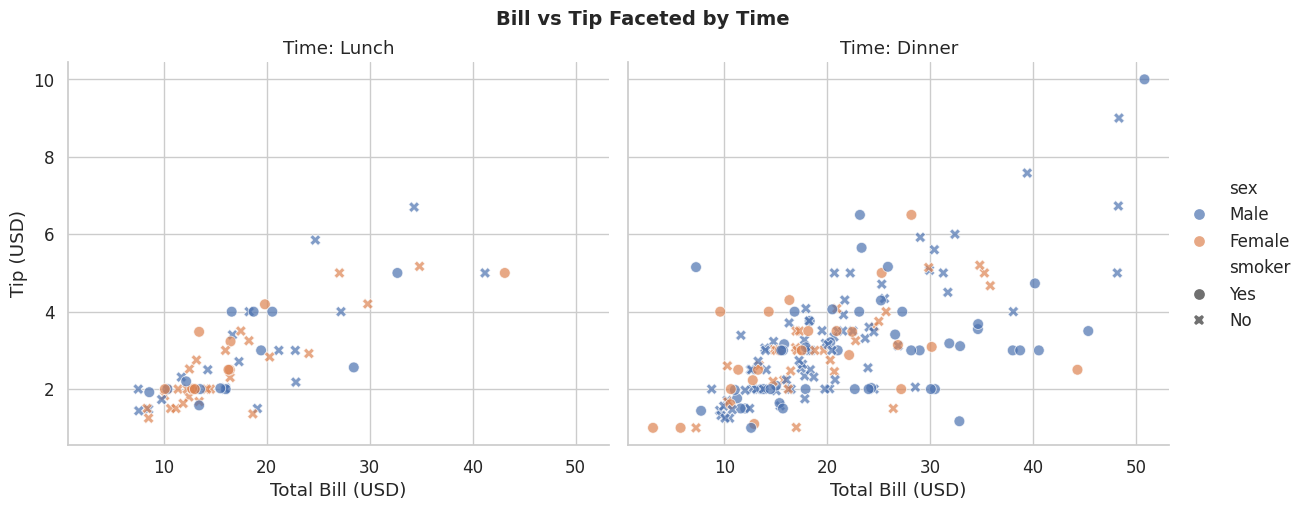

Faceted scatter saved!


In [5]:
# --- SCATTER 3: Figure-level scatter with faceting ---
# relplot creates the figure itself - no plt.subplots() needed
# col='time' splits the chart into two columns: Lunch and Dinner
# Now you can compare the pattern separately for each time period

g = sns.relplot(
    data=tips,
    x='total_bill',
    y='tip',
    hue='sex',
    style='smoker',
    col='time',          # split into columns by 'time' (Lunch | Dinner)
    kind='scatter',
    height=5,            # height of each subplot in inches
    aspect=1.2,          # width = height * aspect
    alpha=0.7,
    s=60
)

# g is a FacetGrid object, not an axes
# To set titles and labels on FacetGrid:
g.set_axis_labels('Total Bill (USD)', 'Tip (USD)')
g.set_titles(col_template='Time: {col_name}')  # custom facet title format
g.figure.suptitle('Bill vs Tip Faceted by Time', fontsize=14, fontweight='bold', y=1.02)

plt.savefig('day18_charts/1c_scatter_facet.png', dpi=150, bbox_inches='tight')
plt.show()
print('Faceted scatter saved!')

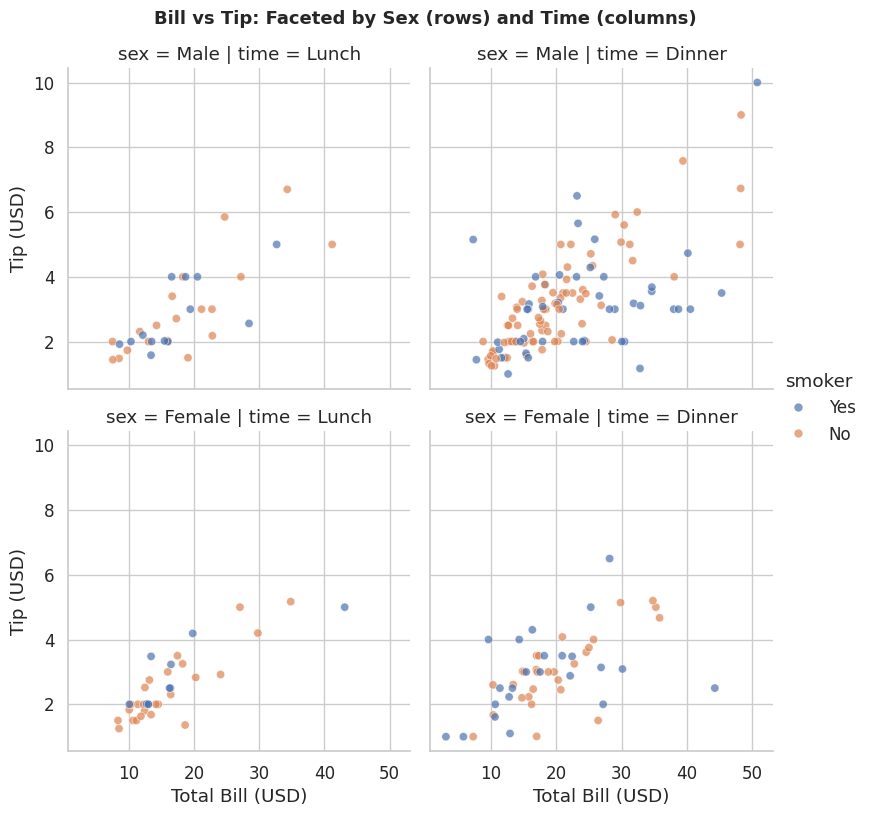

2D facet grid scatter saved!


In [6]:
# --- SCATTER 4: Facet with col= AND row= (2D grid) ---
# col='time' creates columns (Lunch, Dinner)
# row='sex' creates rows (Male, Female)
# Result: 2x2 grid showing all combinations

g = sns.relplot(
    data=tips,
    x='total_bill',
    y='tip',
    hue='smoker',
    col='time',
    row='sex',           # add row dimension
    kind='scatter',
    height=4,
    aspect=1.0,
    alpha=0.7
)

g.set_axis_labels('Total Bill (USD)', 'Tip (USD)')
g.figure.suptitle('Bill vs Tip: Faceted by Sex (rows) and Time (columns)',
                   fontsize=13, fontweight='bold', y=1.02)

plt.savefig('day18_charts/1d_scatter_row_col_facet.png', dpi=150, bbox_inches='tight')
plt.show()
print('2D facet grid scatter saved!')

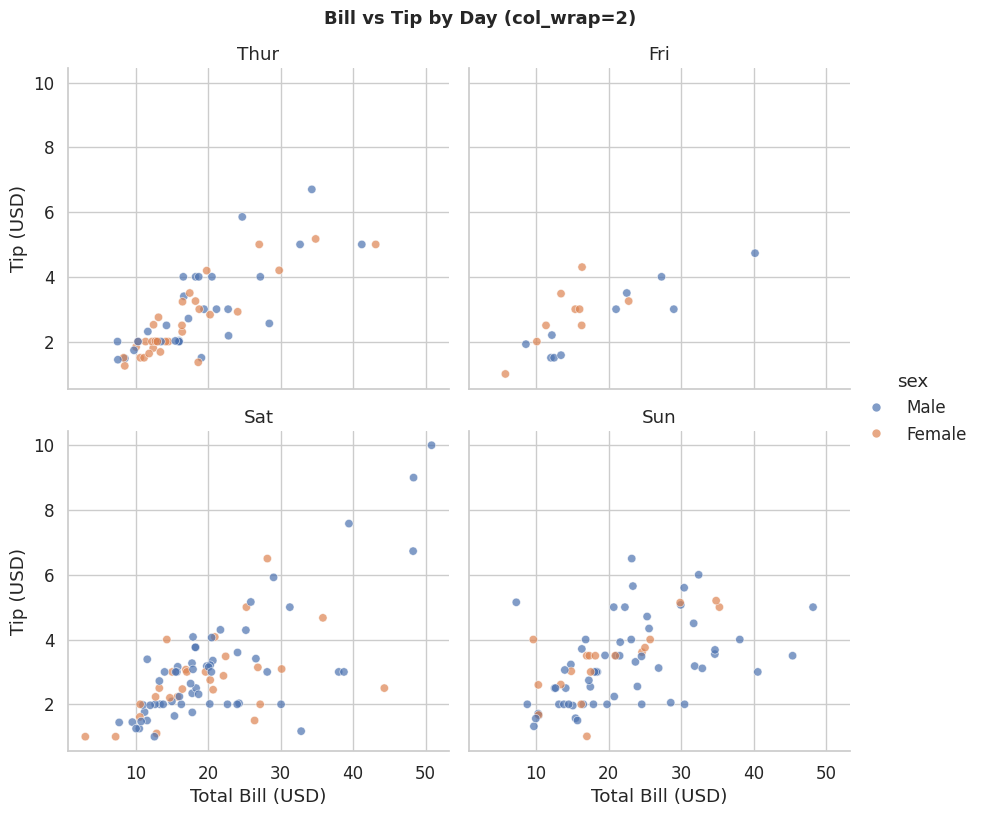

col_wrap facet saved!


In [7]:
# --- SCATTER 5: col_wrap - wrapping into multiple rows ---
# When you have many categories in one column, col= would create too many columns
# col_wrap=2 says: put at most 2 charts per row, wrap to next row after that

g = sns.relplot(
    data=tips,
    x='total_bill',
    y='tip',
    hue='sex',
    col='day',           # 4 unique days: Thur, Fri, Sat, Sun
    col_wrap=2,          # max 2 per row, so we get a 2x2 grid
    kind='scatter',
    height=4,
    aspect=1.1,
    alpha=0.7
)

g.set_axis_labels('Total Bill (USD)', 'Tip (USD)')
g.set_titles(col_template='{col_name}')
g.figure.suptitle('Bill vs Tip by Day (col_wrap=2)', fontsize=13, fontweight='bold', y=1.02)

plt.savefig('day18_charts/1e_scatter_col_wrap.png', dpi=150, bbox_inches='tight')
plt.show()
print('col_wrap facet saved!')

### What you just learned about Scatter and Faceting:

- `sns.scatterplot(data=, x=, y=, hue=, style=, size=, sizes=, alpha=, ax=)` - axis-level scatter
- `hue=` - colors by a column. Categorical = qualitative palette. Numerical = sequential palette.
- `style=` - changes the dot shape (marker) by a column.
- `size=` - changes dot size by a column. `sizes=(min, max)` controls the range.
- `sns.relplot(..., kind='scatter')` - figure-level scatter. Creates its own figure.
- `col='column'` - splits chart into columns by unique values of that column.
- `row='column'` - splits chart into rows.
- `col_wrap=n` - when using col=, wrap after n charts per row.
- `height=`, `aspect=` - size controls for figure-level functions.
- FacetGrid methods: `g.set_axis_labels()`, `g.set_titles()`, `g.figure.suptitle()`

**Key insight:** Use `col=` when you want to compare the same chart across different subgroups. The patterns become immediately obvious.

---

# Part 4: Line Plot - Trends and Averages

## What sns.lineplot Does Automatically

Here is a critical difference from Matplotlib's plt.plot():

When you give Seaborn's lineplot data with multiple y-values per x-value, it:
1. Calculates the MEAN of y at each x value
2. Draws the line through those means
3. Automatically draws a shaded confidence interval (95% by default) around the line

This is a statistical feature. Matplotlib just connects all points with a line in order. Seaborn aggregates and shows uncertainty.

For the tips dataset, we do not have a time variable naturally. So we will use `day` as the x-axis and show average tip per day. Lineplot will show the mean + confidence interval automatically.

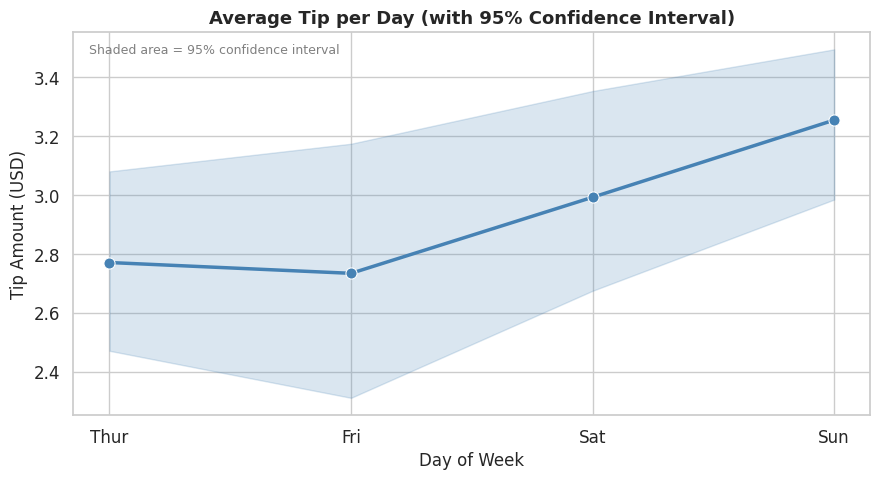

Line plot saved!


In [8]:
# --- LINE 1: Average tip per day with confidence interval ---

fig, ax = plt.subplots(figsize=(9, 5))

# Logical order of days
day_order = ['Thur', 'Fri', 'Sat', 'Sun']

# Convert day column into ordered categorical
tips['day'] = pd.Categorical(
    tips['day'],
    categories=day_order,
    ordered=True
)

# Sort dataframe
tips = tips.sort_values('day')

# lineplot automatically computes mean and 95% confidence interval
sns.lineplot(
    data=tips,
    x='day',
    y='tip',
    marker='o',
    linewidth=2.5,
    markersize=8,
    color='steelblue',
    ax=ax
)

ax.set_title(
    'Average Tip per Day (with 95% Confidence Interval)',
    fontsize=13,
    fontweight='bold'
)

ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Tip Amount (USD)', fontsize=12)

# Annotation
ax.text(
    0.02,
    0.97,
    'Shaded area = 95% confidence interval',
    transform=ax.transAxes,
    fontsize=9,
    color='gray',
    va='top'
)

plt.tight_layout()

plt.savefig(
    'day18_charts/2a_line_avg_tip.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print('Line plot saved!')

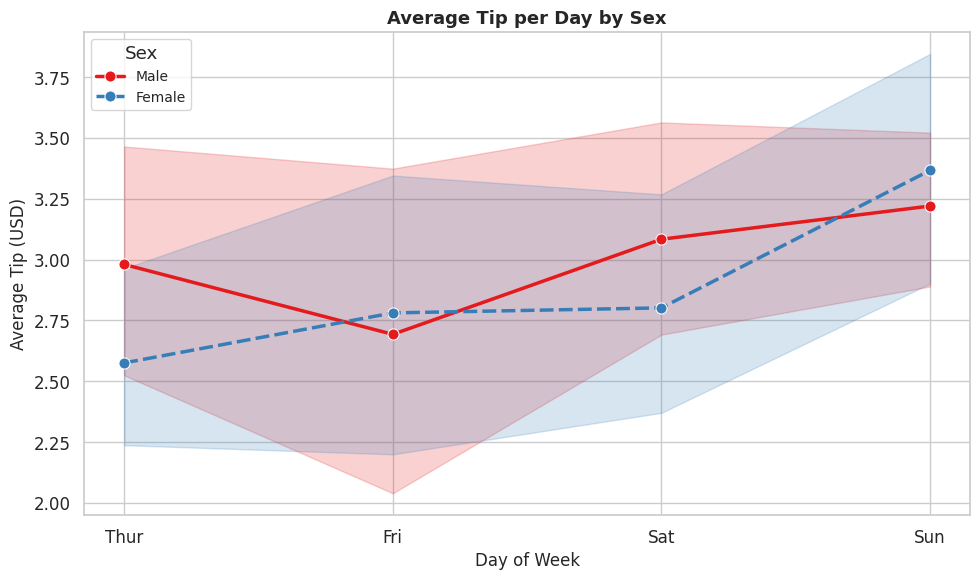

In [10]:
# LINE 2: Separate lines per group using hue

# hue='sex' → Male aur Female ke liye separate line
# style='sex' → line style bhi different hoga
# marker='o' → har data point pe circle marker

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Custom order for days
day_order = ['Thur', 'Fri', 'Sat', 'Sun']

# Convert 'day' column into ordered categorical type
tips['day'] = pd.Categorical(
    tips['day'],
    categories=day_order,
    ordered=True
)

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Line plot
sns.lineplot(
    data=tips,
    x='day',
    y='tip',
    hue='sex',           # Separate line for each sex
    style='sex',         # Different line styles
    marker='o',          # Circle markers
    markersize=8,
    linewidth=2.5,
    palette='Set1',
    ax=ax
)

# Titles and labels
ax.set_title(
    'Average Tip per Day by Sex',
    fontsize=13,
    fontweight='bold'
)

ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Average Tip (USD)', fontsize=12)

# Legend settings
ax.legend(title='Sex', fontsize=10)

# Adjust layout
plt.tight_layout()

# Save figure
plt.savefig(
    'day18_charts/2b_line_hue.png',
    dpi=150,
    bbox_inches='tight'
)

# Show plot
plt.show()

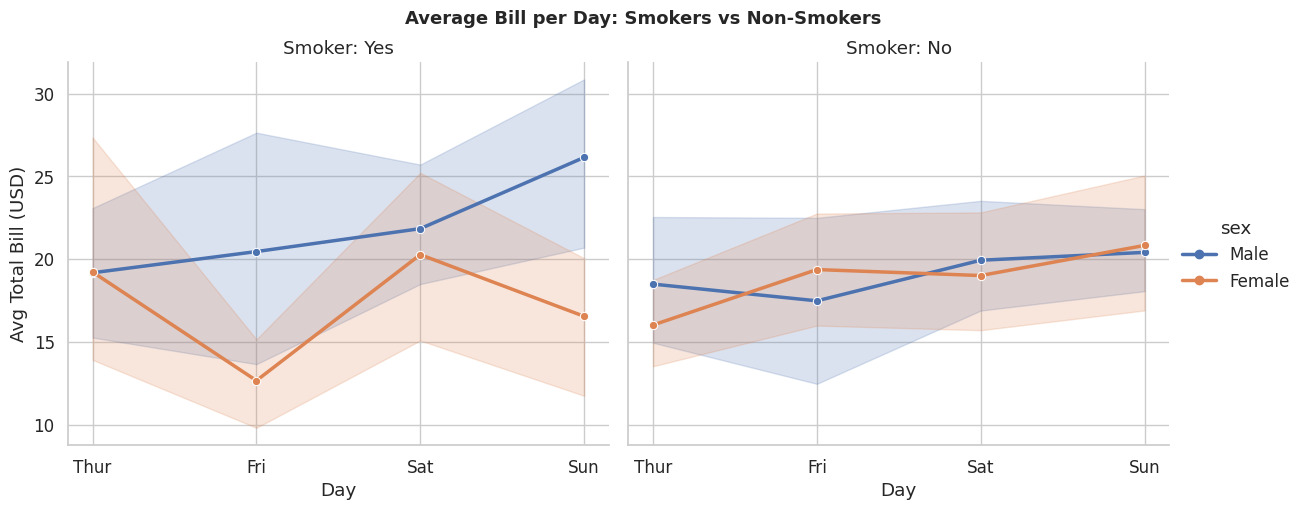

Line facet plot saved!


In [11]:
# --- LINE 3: Figure-level lineplot with faceting ---
# relplot with kind='line'

g = sns.relplot(
    data=tips,
    x='day',
    y='total_bill',
    hue='sex',
    col='smoker',        # split into smoker vs non-smoker columns
    kind='line',
    marker='o',
    height=5,
    aspect=1.2,
    linewidth=2.5
)

# The day order needs to be set on individual axes
for ax in g.axes.flat:
    ax.set_xlabel('Day')
    ax.set_ylabel('Avg Total Bill (USD)')

g.set_titles(col_template='Smoker: {col_name}')
g.figure.suptitle('Average Bill per Day: Smokers vs Non-Smokers',
                   fontsize=13, fontweight='bold', y=1.02)

plt.savefig('day18_charts/2c_line_facet.png', dpi=150, bbox_inches='tight')
plt.show()
print('Line facet plot saved!')

---

# Part 5: Histogram - Distribution of One Variable

## sns.histplot vs plt.hist

Both create histograms but sns.histplot is much more powerful:

- `hue=` - overlays multiple histograms (one per category) in different colors. In plt.hist you would need a loop.
- `element='bars'/'step'/'poly'` - changes how the histogram is drawn
- `stat='count'/'density'/'probability'/'percent'` - changes what the y-axis shows
- `kde=True` - overlays a KDE curve on top of the histogram
- `multiple='layer'/'dodge'/'stack'/'fill'` - controls how multiple hue groups are shown

---

## element parameter - Three Ways to Draw a Histogram

- `element='bars'` - standard bars (default). Each bin is a filled rectangle.
- `element='step'` - outline only, no fill. Like a staircase shape. Useful when histograms overlap, as it is easier to see both.
- `element='poly'` - connects bin tops with lines. A polygon, not bars.

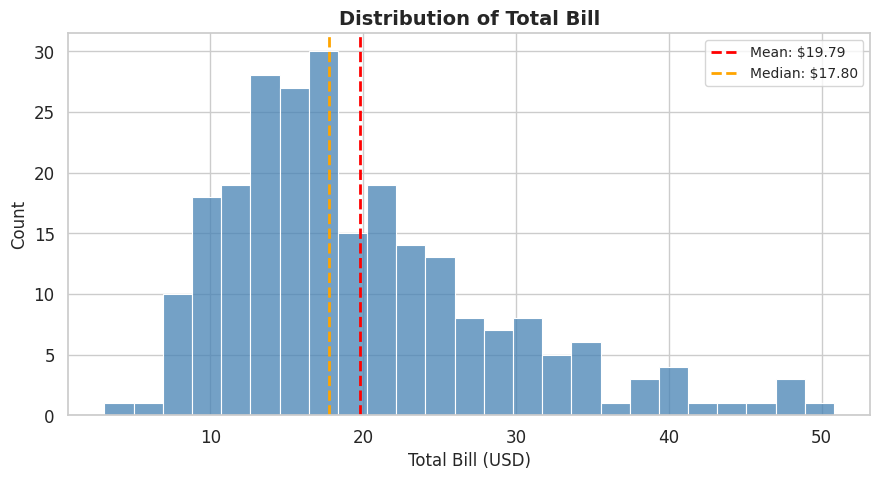

In [12]:
# --- HISTOGRAM 1: Simple histogram ---
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(
    data=tips,
    x='total_bill',
    bins=25,
    color='steelblue',
    edgecolor='white',
    linewidth=0.8,
    ax=ax
)

ax.set_title('Distribution of Total Bill', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Bill (USD)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)

# Add mean and median lines
ax.axvline(tips['total_bill'].mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean: ${tips["total_bill"].mean():.2f}')
ax.axvline(tips['total_bill'].median(), color='orange', linestyle='--', linewidth=2,
           label=f'Median: ${tips["total_bill"].median():.2f}')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('day18_charts/3a_histogram_simple.png', dpi=150, bbox_inches='tight')
plt.show()

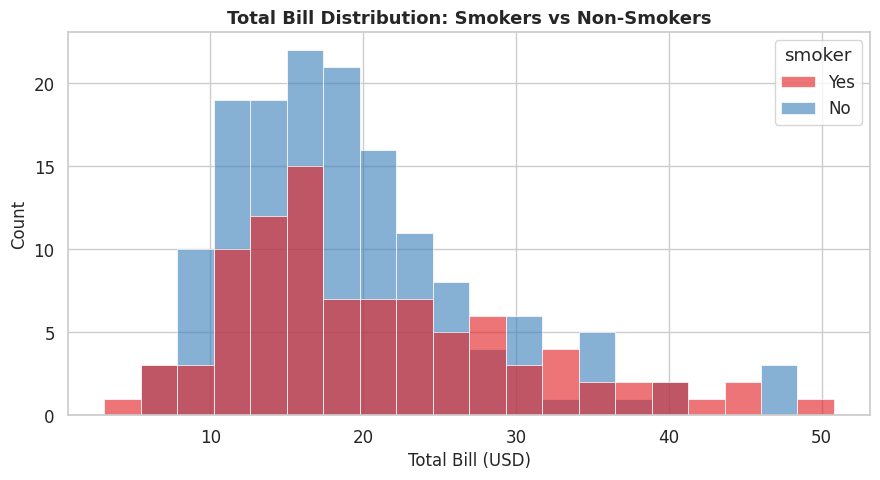

In [13]:
# --- HISTOGRAM 2: hue overlaid ---
# hue='smoker' draws two overlapping histograms: one for smokers, one for non-smokers
# multiple='layer' means they overlap (one on top of the other)
# alpha makes them semi-transparent so both are visible

fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(
    data=tips,
    x='total_bill',
    hue='smoker',
    bins=20,
    multiple='layer',    # overlap the two histograms
    alpha=0.6,
    palette='Set1',
    edgecolor='white',
    linewidth=0.5,
    ax=ax
)

ax.set_title('Total Bill Distribution: Smokers vs Non-Smokers', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Bill (USD)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)

plt.tight_layout()
plt.savefig('day18_charts/3b_histogram_hue.png', dpi=150, bbox_inches='tight')
plt.show()

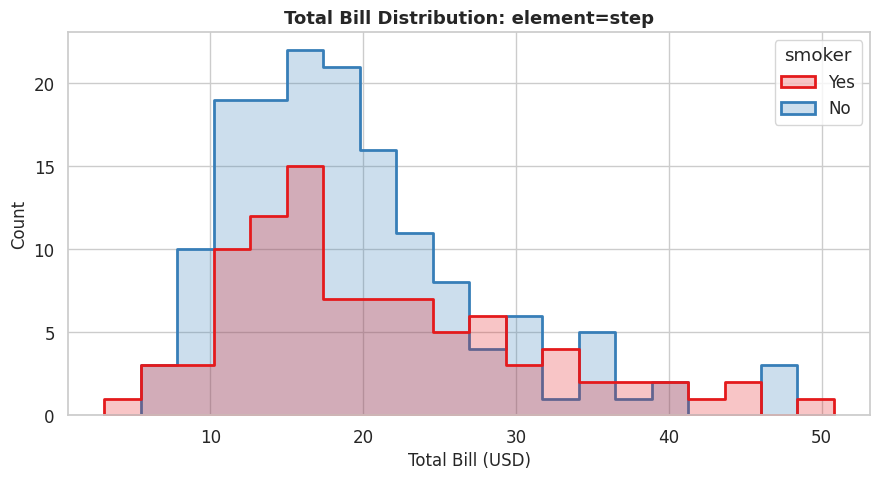

In [14]:
# --- HISTOGRAM 3: element='step' ---
# Step histogram: only the outline, no fill
# Much easier to see overlap between two groups

fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(
    data=tips,
    x='total_bill',
    hue='smoker',
    bins=20,
    element='step',      # outline only, no fill - easier to read when overlapping
    linewidth=2,
    palette='Set1',
    ax=ax
)

ax.set_title('Total Bill Distribution: element=step', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Bill (USD)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)

plt.tight_layout()
plt.savefig('day18_charts/3c_histogram_step.png', dpi=150, bbox_inches='tight')
plt.show()

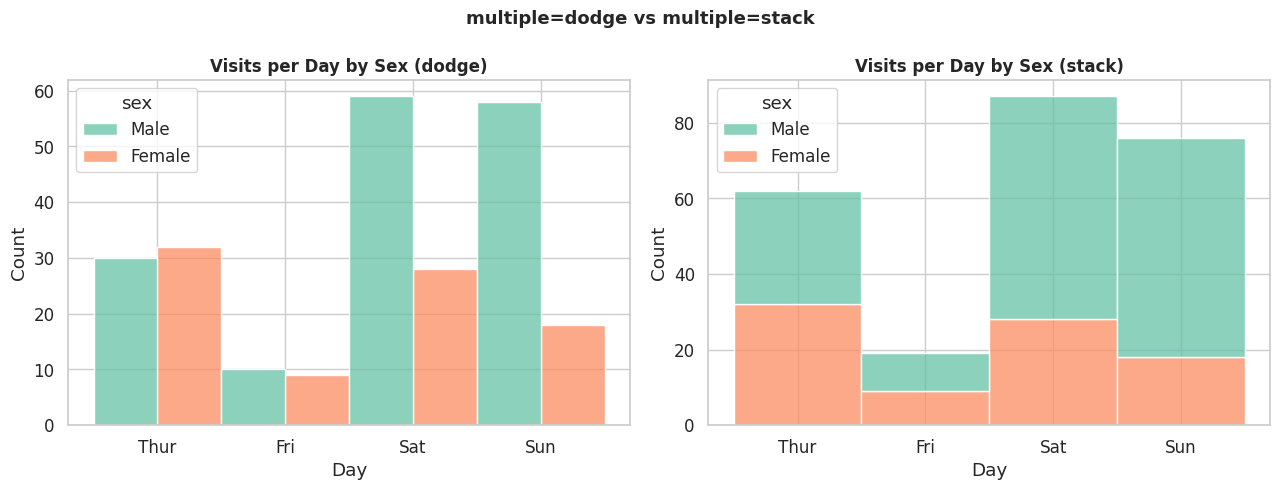

In [15]:
# --- HISTOGRAM 4: On a categorical column ---
# Histplot can also work on categorical x - it becomes essentially a count plot
# But countplot is more appropriate for pure categorical data
# This shows how to use histplot with discrete/categorical data

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: count per day
sns.histplot(data=tips, x='day', hue='sex', multiple='dodge',
             palette='Set2', edgecolor='white', ax=axes[0])
axes[0].set_title('Visits per Day by Sex (dodge)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Count')

# Right: count per day, stacked
sns.histplot(data=tips, x='day', hue='sex', multiple='stack',
             palette='Set2', edgecolor='white', ax=axes[1])
axes[1].set_title('Visits per Day by Sex (stack)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Count')

plt.suptitle('multiple=dodge vs multiple=stack', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('day18_charts/3d_histogram_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

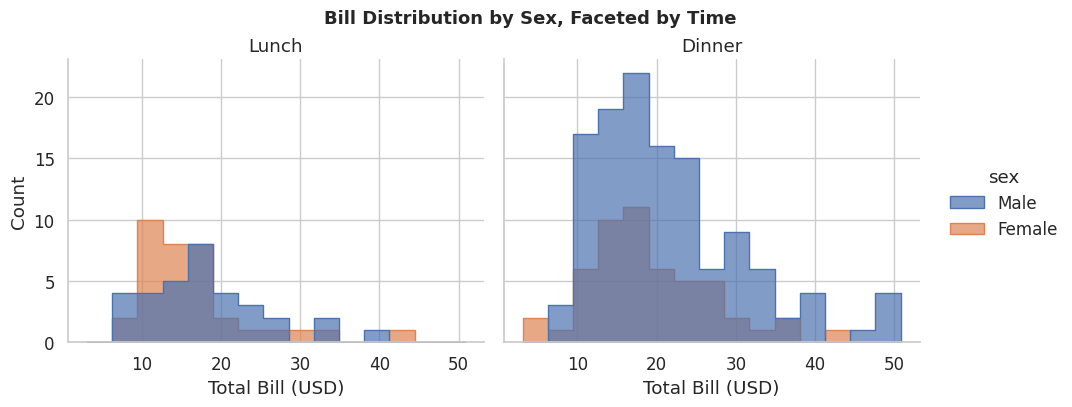

All histograms saved!


In [16]:
# --- HISTOGRAM 5: Figure-level with displot and faceting ---
g = sns.displot(
    data=tips,
    x='total_bill',
    hue='sex',
    col='time',          # facet by time: Lunch | Dinner
    kind='hist',
    bins=15,
    height=4,
    aspect=1.2,
    alpha=0.7,
    element='step'
)

g.set_axis_labels('Total Bill (USD)', 'Count')
g.set_titles(col_template='{col_name}')
g.figure.suptitle('Bill Distribution by Sex, Faceted by Time', fontsize=13, fontweight='bold', y=1.02)

plt.savefig('day18_charts/3e_histogram_displot.png', dpi=150, bbox_inches='tight')
plt.show()
print('All histograms saved!')

### What you just learned about Histograms:

- `sns.histplot(data=, x=, bins=, hue=, multiple=, element=, stat=)` - axis-level
- `hue=` - overlays multiple histograms in different colors
- `multiple='layer'` - overlapping (use alpha for transparency)
- `multiple='dodge'` - side by side bars per bin (like grouped bar chart)
- `multiple='stack'` - stacked bars per bin
- `multiple='fill'` - each bin fills to 100% (shows proportions not counts)
- `element='bars'` - default filled bars
- `element='step'` - outline only, best for overlapping groups
- `element='poly'` - polygon (connected tops of bars)
- `stat='count'` - y-axis shows count (default)
- `stat='density'` - y-axis shows probability density (area under curve = 1)
- `stat='percent'` - y-axis shows percentage of total

---

# Part 6: KDE Plot - The Smooth Version of a Histogram

## What is KDE?

KDE stands for Kernel Density Estimation.

A histogram is a rough approximation of the data distribution. The shape depends heavily on how many bins you choose and where they start. Change bins from 10 to 20, and the histogram looks completely different, even though the data is identical.

KDE solves this problem by creating a smooth continuous curve that estimates the true underlying distribution.

**How KDE works conceptually:**
1. Place a small bell-shaped curve (Gaussian kernel) at each data point
2. Add all these bell curves together
3. The result is a smooth curve showing where data is dense (tall) and sparse (flat)

The result is the probability density curve. The area under the entire KDE curve always equals 1.

---

## KDE vs Histogram: When to Use Which

Use **histogram** when:
- You need to show exact counts
- Your audience is non-technical (bars are more intuitive)
- You have small data (KDE smoothing needs enough points to work well)

Use **KDE** when:
- You want to compare distributions visually (KDE curves overlap cleanly)
- You care about the shape of the distribution, not the count
- You have enough data (100+ points ideally)
- You want a cleaner, smoother look for presentations

---

## The bw_adjust Parameter

This controls how smooth the KDE curve is.
- Low bw_adjust (e.g., 0.3) = rough, follows every bump in the data
- High bw_adjust (e.g., 2.0) = very smooth, may over-generalize
- Default (1.0) = balanced

bw = bandwidth. Think of it as how "wide" each bell curve kernel is.

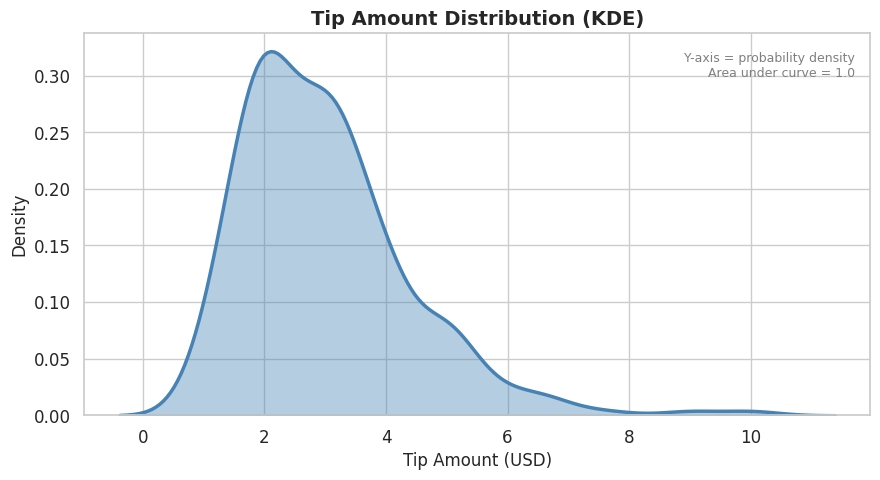

In [17]:
# --- KDE 1: Simple KDE ---
fig, ax = plt.subplots(figsize=(9, 5))

sns.kdeplot(
    data=tips,
    x='tip',
    fill=True,           # fill the area under the curve (shaded)
    color='steelblue',
    alpha=0.4,
    linewidth=2.5,
    ax=ax
)

ax.set_title('Tip Amount Distribution (KDE)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tip Amount (USD)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)

# Explain what density means
ax.text(0.98, 0.95, 'Y-axis = probability density\nArea under curve = 1.0',
        transform=ax.transAxes, fontsize=9, color='gray',
        va='top', ha='right')

plt.tight_layout()
plt.savefig('day18_charts/4a_kde_simple.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_6567/1177744780.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Day', fontsize=10)


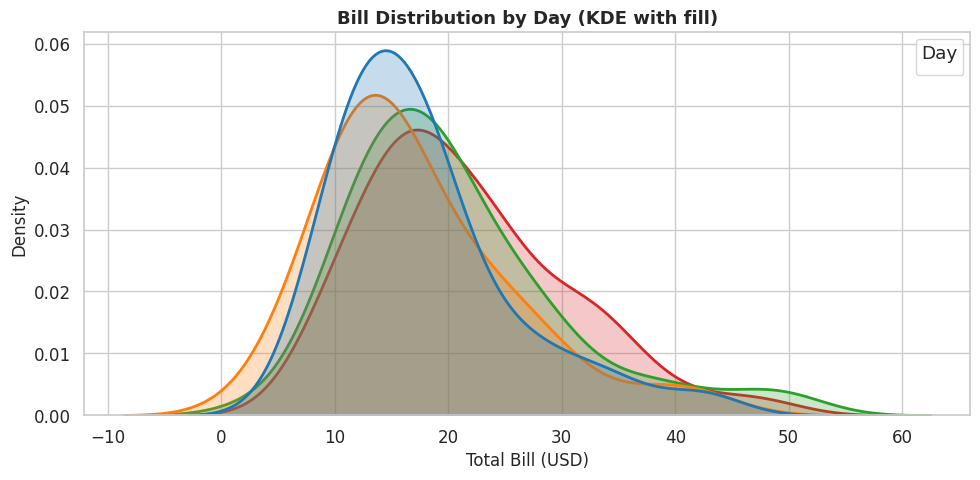

In [18]:
# --- KDE 2: Multiple groups with hue ---
# KDE is ideal for comparing distributions between groups
# The smooth curves overlap cleanly - much easier to compare than histograms

fig, ax = plt.subplots(figsize=(10, 5))

sns.kdeplot(
    data=tips,
    x='total_bill',
    hue='day',           # one curve per day
    fill=True,
    alpha=0.25,          # semi-transparent so all curves visible
    linewidth=2,
    palette='tab10',
    common_norm=False,   # each curve normalized independently
                         # True would normalize all together (changes heights)
    ax=ax
)

ax.set_title('Bill Distribution by Day (KDE with fill)', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Bill (USD)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(title='Day', fontsize=10)

plt.tight_layout()
plt.savefig('day18_charts/4b_kde_hue.png', dpi=150, bbox_inches='tight')
plt.show()

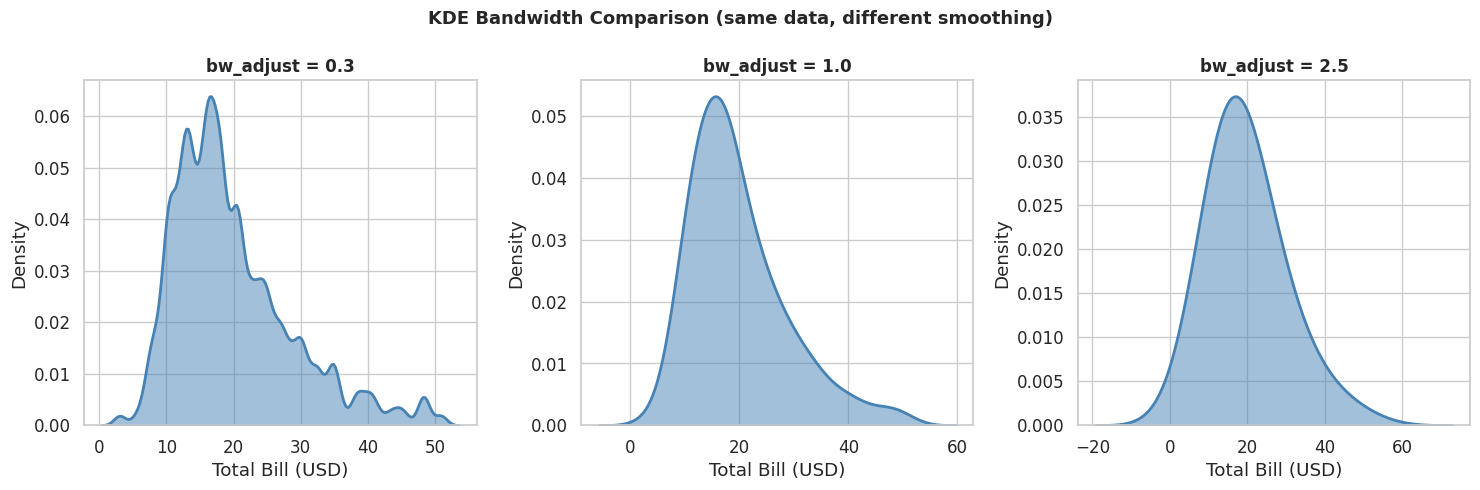

Low bw: follows every bump. High bw: over-smoothed. Default 1.0: balanced.


In [19]:
# --- KDE 3: bw_adjust comparison ---
# See how bandwidth affects the smoothness of the curve

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, bw in zip(axes, [0.3, 1.0, 2.5]):
    sns.kdeplot(data=tips, x='total_bill', fill=True, alpha=0.5,
                linewidth=2, bw_adjust=bw, color='steelblue', ax=ax)
    ax.set_title(f'bw_adjust = {bw}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Total Bill (USD)')
    ax.set_ylabel('Density')

plt.suptitle('KDE Bandwidth Comparison (same data, different smoothing)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('day18_charts/4c_kde_bandwidth.png', dpi=150, bbox_inches='tight')
plt.show()
print('Low bw: follows every bump. High bw: over-smoothed. Default 1.0: balanced.')

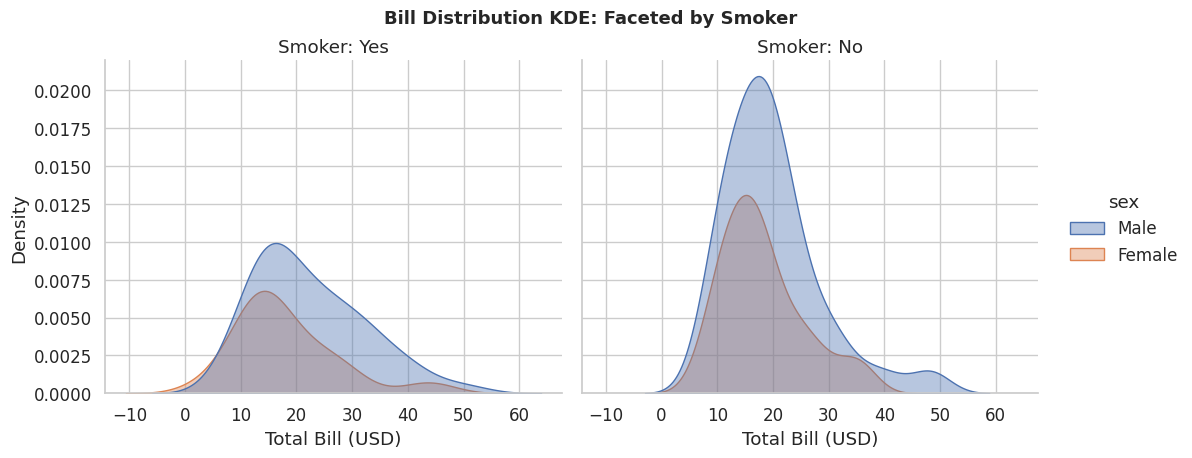

All KDE plots saved!


In [20]:
# --- KDE 4: Figure-level KDE with displot ---
g = sns.displot(
    data=tips,
    x='total_bill',
    hue='sex',
    col='smoker',
    kind='kde',          # kind='kde' for KDE plots in displot
    fill=True,
    alpha=0.4,
    height=4.5,
    aspect=1.2
)

g.set_axis_labels('Total Bill (USD)', 'Density')
g.set_titles(col_template='Smoker: {col_name}')
g.figure.suptitle('Bill Distribution KDE: Faceted by Smoker', fontsize=13, fontweight='bold', y=1.02)

plt.savefig('day18_charts/4d_kde_displot.png', dpi=150, bbox_inches='tight')
plt.show()
print('All KDE plots saved!')

---

# Part 7: Rug Plot - Showing Individual Observations

## What is a Rug Plot?

A rug plot draws a tiny vertical tick mark at each individual data point's position along an axis.

Imagine you have 244 data points. Each one gets a small tick on the x-axis at its value. The result looks like a rug (many short vertical lines along the bottom).

**Why use it?**

KDE and histograms show the distribution shape, but they hide the individual points. A rug plot shows you where each actual observation falls.

Combined with a KDE curve: you see both the smooth distribution estimate AND the raw data. Dense clusters of ticks explain tall KDE peaks. Sparse ticks explain flat areas.

**When to avoid it:** With more than 500 points, the ticks start overlapping and become unreadable. At that scale, just use a histogram or KDE.

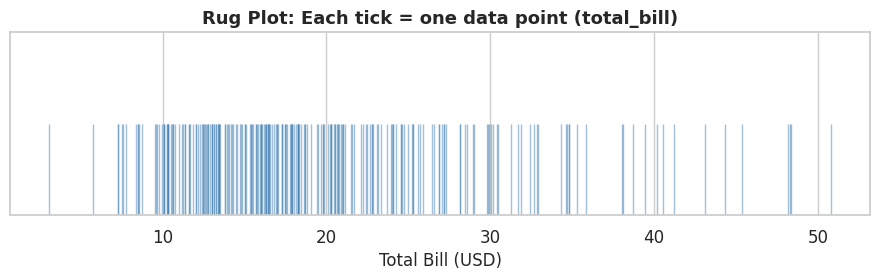

In [21]:
# --- RUG PLOT 1: Standalone rug plot ---
fig, ax = plt.subplots(figsize=(9, 3))

sns.rugplot(
    data=tips,
    x='total_bill',
    height=0.5,          # height of each tick (as fraction of axes height)
    alpha=0.5,           # transparency (many ticks overlap at the same value)
    color='steelblue',
    ax=ax
)

ax.set_title('Rug Plot: Each tick = one data point (total_bill)', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Bill (USD)', fontsize=12)
ax.set_yticks([])        # no y-axis needed for a rug plot alone

plt.tight_layout()
plt.show()

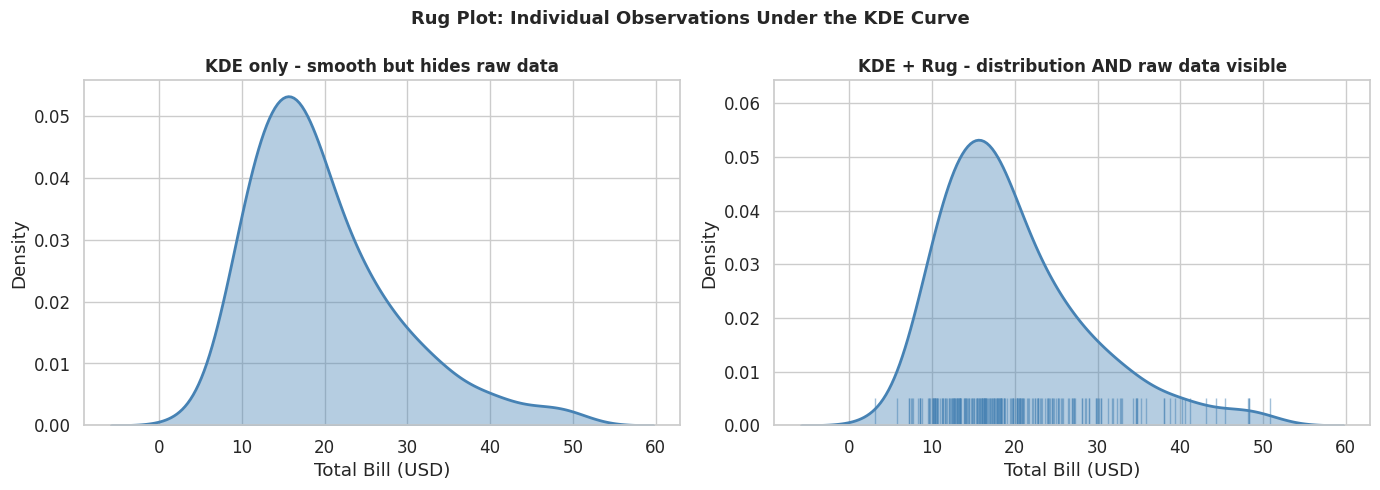

Rug plots saved!


In [22]:
# --- RUG PLOT 2: KDE + Rug combined ---
# This is the most common use of rug plots
# The rug shows where individual data points are
# The KDE shows the smooth estimated distribution
# Together: you understand both the pattern AND the raw data

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: KDE alone
sns.kdeplot(data=tips, x='total_bill', fill=True, alpha=0.4, color='steelblue',
            linewidth=2, ax=axes[0])
axes[0].set_title('KDE only - smooth but hides raw data', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Bill (USD)')
axes[0].set_ylabel('Density')

# Right: KDE + Rug
sns.kdeplot(data=tips, x='total_bill', fill=True, alpha=0.4, color='steelblue',
            linewidth=2, ax=axes[1])
sns.rugplot(data=tips, x='total_bill', height=0.08, alpha=0.5,
            color='steelblue', ax=axes[1])
axes[1].set_title('KDE + Rug - distribution AND raw data visible', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Bill (USD)')
axes[1].set_ylabel('Density')

plt.suptitle('Rug Plot: Individual Observations Under the KDE Curve', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('day18_charts/5_rug_kde.png', dpi=150, bbox_inches='tight')
plt.show()
print('Rug plots saved!')

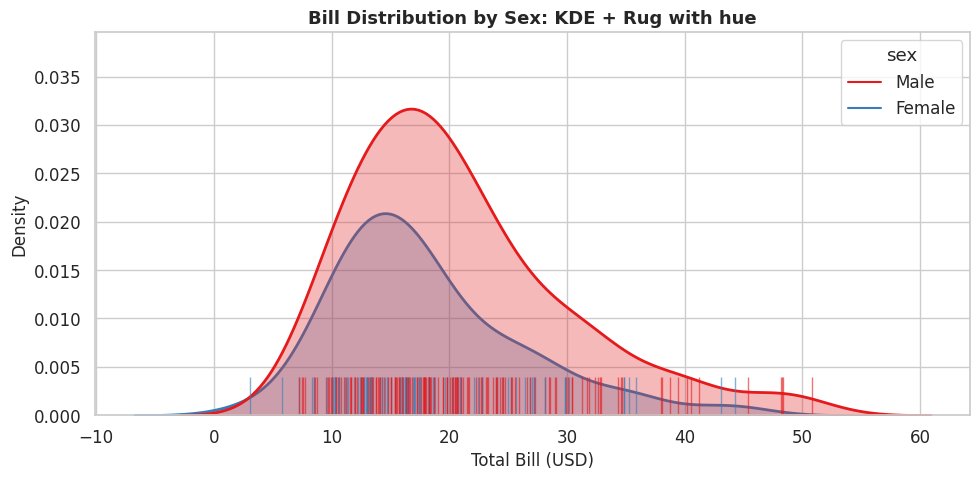

In [23]:
# --- RUG PLOT 3: Rug with hue ---
fig, ax = plt.subplots(figsize=(10, 5))

sns.kdeplot(data=tips, x='total_bill', hue='sex', fill=True, alpha=0.3,
            linewidth=2, palette='Set1', ax=ax)

# Rug with hue - each group gets a different color tick
sns.rugplot(data=tips, x='total_bill', hue='sex', height=0.1,
            palette='Set1', alpha=0.6, ax=ax)

ax.set_title('Bill Distribution by Sex: KDE + Rug with hue', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Bill (USD)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)

plt.tight_layout()
plt.savefig('day18_charts/5b_rug_hue.png', dpi=150, bbox_inches='tight')
plt.show()

---

# Part 8: Bivariate Plots - Looking at Two Variables Simultaneously

## What is a Bivariate Distribution?

So far, all our histograms and KDE plots looked at ONE variable at a time. That is called a univariate distribution.

A bivariate distribution looks at TWO variables together - how do their values co-occur?

For example: Given a bill of $15-20, what are the most common tip amounts? The answer requires a bivariate view.

---

## Two Types of Bivariate Plots

**2D Histogram (also called density map):** Divide the x-y space into a grid of bins. Color each bin by how many data points fall in it. Dark = many points, light = few.

**2D KDE:** Same idea but smooth. Instead of a grid of bins, compute a smooth density surface. Shows the probability density at every (x, y) point.

Both answer: where are data points most concentrated in 2D space?

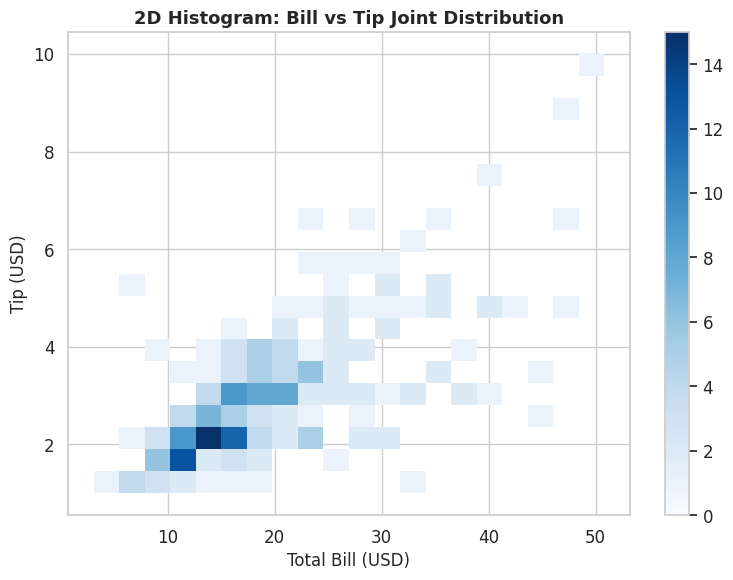

In [24]:
# --- BIVARIATE 1: 2D Histogram ---
# histplot with BOTH x= and y= creates a 2D histogram

fig, ax = plt.subplots(figsize=(8, 6))

sns.histplot(
    data=tips,
    x='total_bill',
    y='tip',            # BOTH x and y = 2D histogram
    bins=20,
    cmap='Blues',       # for 2D histplot, color map is used
    cbar=True,          # show colorbar
    ax=ax
)

ax.set_title('2D Histogram: Bill vs Tip Joint Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Bill (USD)', fontsize=12)
ax.set_ylabel('Tip (USD)', fontsize=12)

plt.tight_layout()
plt.savefig('day18_charts/6a_bivariate_2d_hist.png', dpi=150, bbox_inches='tight')
plt.show()

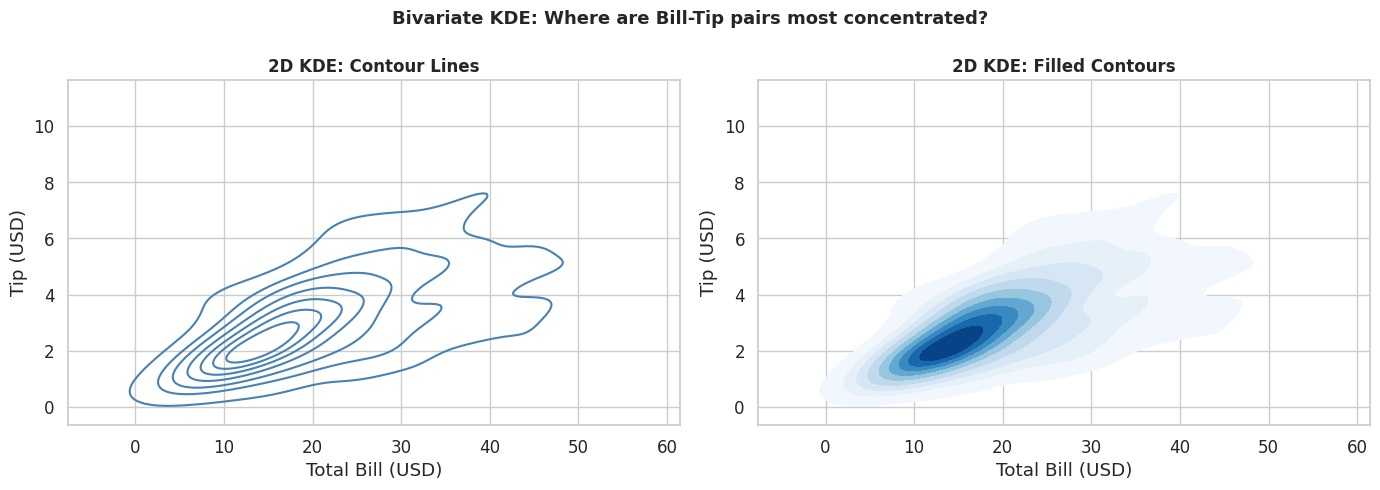

In [25]:
# --- BIVARIATE 2: 2D KDE ---
# kdeplot with both x= and y= creates a 2D KDE
# Shows the probability density surface as contour lines (or filled contours)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: 2D KDE with contour lines only
sns.kdeplot(
    data=tips,
    x='total_bill',
    y='tip',
    levels=8,            # number of contour lines
    color='steelblue',
    linewidths=1.5,
    ax=axes[0]
)
axes[0].set_title('2D KDE: Contour Lines', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Bill (USD)')
axes[0].set_ylabel('Tip (USD)')

# Right: 2D KDE with filled contours
sns.kdeplot(
    data=tips,
    x='total_bill',
    y='tip',
    fill=True,           # fill contours with color (like a heatmap)
    cmap='Blues',
    levels=10,
    thresh=0.05,         # ignore regions below 5% density (cleaner edges)
    ax=axes[1]
)
axes[1].set_title('2D KDE: Filled Contours', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Bill (USD)')
axes[1].set_ylabel('Tip (USD)')

plt.suptitle('Bivariate KDE: Where are Bill-Tip pairs most concentrated?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('day18_charts/6b_bivariate_2d_kde.png', dpi=150, bbox_inches='tight')
plt.show()

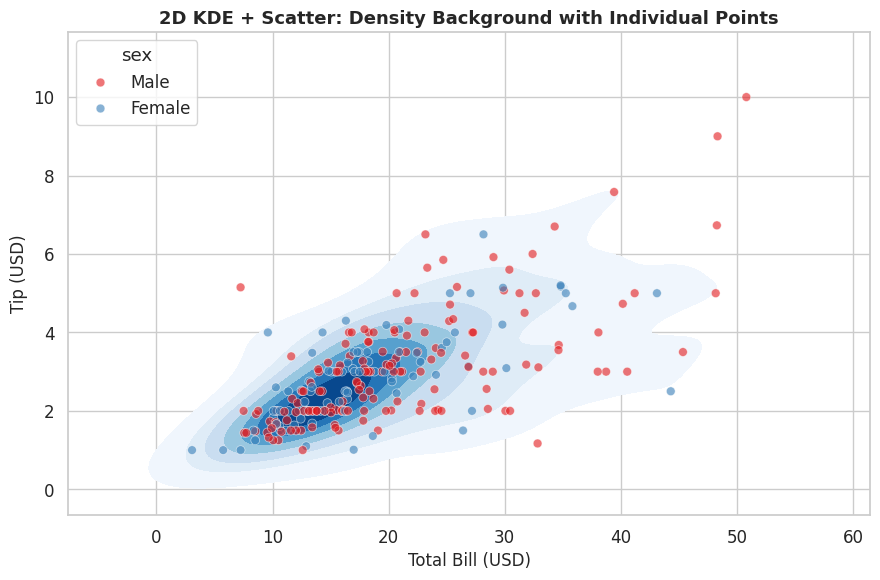

Bivariate plots saved!


In [26]:
# --- BIVARIATE 3: 2D KDE with scatter overlay ---
# Great combination: show density AND individual points

fig, ax = plt.subplots(figsize=(9, 6))

# First: 2D KDE as background
sns.kdeplot(data=tips, x='total_bill', y='tip', fill=True, cmap='Blues',
            levels=8, thresh=0.05, ax=ax)

# Second: scatter plot on top
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='sex',
                alpha=0.6, s=40, palette='Set1', ax=ax)

ax.set_title('2D KDE + Scatter: Density Background with Individual Points',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Total Bill (USD)', fontsize=12)
ax.set_ylabel('Tip (USD)', fontsize=12)

plt.tight_layout()
plt.savefig('day18_charts/6c_bivariate_kde_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Bivariate plots saved!')

---

# Part 9: Heatmap

## sns.heatmap vs Matplotlib's imshow

In Day 17 we made heatmaps using Matplotlib's `ax.imshow()`. That required manual code to:
- Set tick positions
- Set tick labels
- Loop through all cells to add value labels

Seaborn's `sns.heatmap()` does all of this in one call:
- It reads row and column labels directly from a DataFrame
- `annot=True` adds the value inside each cell automatically
- `linewidth=` adds dividing lines between cells
- `fmt=` controls the format of the annotation text

---

## pivot_table to Create the 2D Grid

`sns.heatmap()` needs a 2D matrix as input - not a raw long-format DataFrame.

The workflow is:
1. Use `pd.pivot_table()` to aggregate data into a 2D grid
2. Pass that pivot table to `sns.heatmap()`

`pivot_table(index='row_col', columns='col_col', values='value_col', aggfunc='mean')` creates a 2D table where:
- Rows = unique values of the `index` column
- Columns = unique values of the `columns` column
- Each cell = aggregated `values` (mean by default)

In [27]:
# --- HEATMAP 1: Average bill per day and time ---

# Step 1: Create pivot table
# rows = day, columns = time, values = average total_bill
pivot_bill = tips.pivot_table(
    index='day',
    columns='time',
    values='total_bill',
    aggfunc='mean'
)

print('Pivot table (mean total_bill per day x time):')
print(pivot_bill)
print()
print('This 2D matrix is exactly what heatmap needs')

Pivot table (mean total_bill per day x time):
time      Lunch     Dinner
day                       
Thur  17.664754  18.780000
Fri   12.845714  19.663333
Sat         NaN  20.441379
Sun         NaN  21.410000

This 2D matrix is exactly what heatmap needs


/tmp/ipykernel_6567/804706521.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_bill = tips.pivot_table(


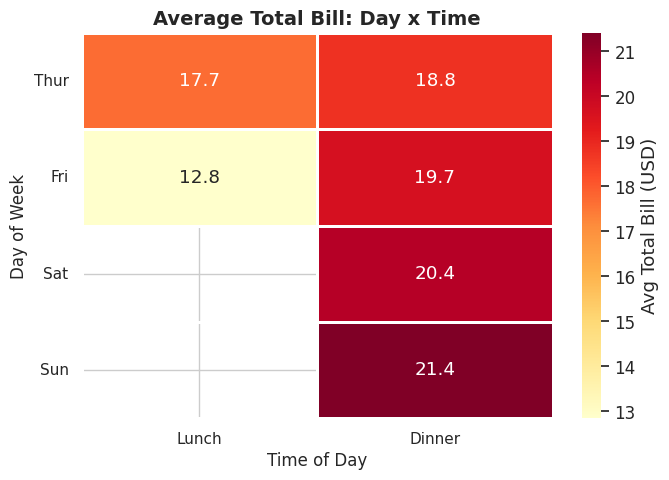

Heatmap saved!


In [28]:
# Step 2: Plot the heatmap
fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    pivot_bill,
    annot=True,          # write the value inside each cell
    fmt='.1f',           # format: 1 decimal place. Use 'd' for integers.
    cmap='YlOrRd',       # colormap
    linewidth=0.8,       # lines between cells (makes it look like a table)
    linecolor='white',
    cbar_kws={'label': 'Avg Total Bill (USD)'},  # colorbar label
    ax=ax
)

ax.set_title('Average Total Bill: Day x Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Time of Day', fontsize=12)
ax.set_ylabel('Day of Week', fontsize=12)

# Rotate x labels
plt.setp(ax.get_xticklabels(), rotation=0, fontsize=11)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=11)

plt.tight_layout()
plt.savefig('day18_charts/7a_heatmap_simple.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap saved!')

Correlation matrix:
            total_bill       tip      size
total_bill    1.000000  0.675734  0.598315
tip           0.675734  1.000000  0.489299
size          0.598315  0.489299  1.000000


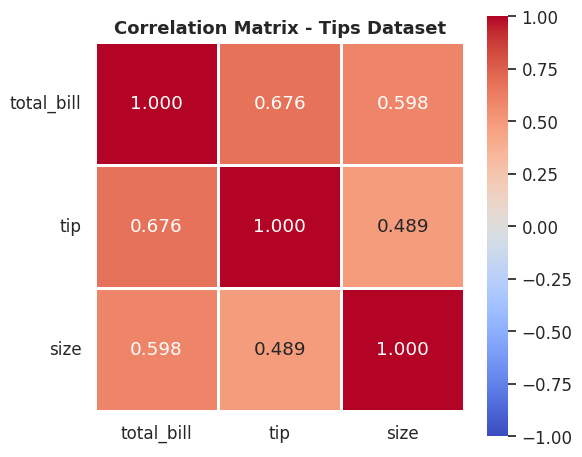

Insight: total_bill and tip have 0.676 correlation - strongly related!


In [29]:
# --- HEATMAP 2: Correlation heatmap ---
# Correlation matrix is one of the most common uses of heatmap in data science
# Tells you: which numerical columns are related to each other?
# Values range from -1 (perfect negative correlation) to +1 (perfect positive)

# Select only numerical columns
tips_num = tips[['total_bill', 'tip', 'size']]
corr_matrix = tips_num.corr()

print('Correlation matrix:')
print(corr_matrix)

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.3f',           # 3 decimal places for correlations
    cmap='coolwarm',     # blue (negative) to red (positive) - perfect for correlations
    vmin=-1, vmax=1,     # force color range to -1 to 1
    center=0,            # center the colormap at 0 (no correlation)
    linewidth=1,
    linecolor='white',
    square=True,         # makes cells square (not stretched)
    ax=ax
)

ax.set_title('Correlation Matrix - Tips Dataset', fontsize=13, fontweight='bold')
plt.setp(ax.get_xticklabels(), rotation=0)
plt.setp(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('day18_charts/7b_heatmap_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: total_bill and tip have 0.676 correlation - strongly related!')

/tmp/ipykernel_6567/3075784649.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_count = tips.pivot_table(


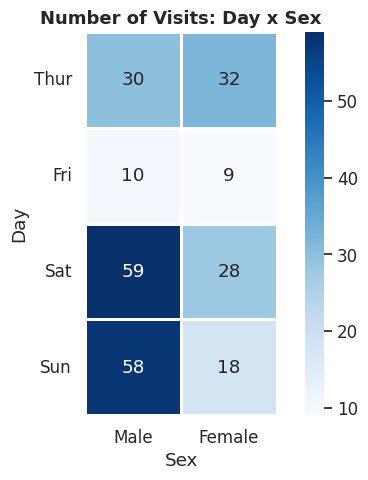

In [30]:
# --- HEATMAP 3: Count heatmap ---
pivot_count = tips.pivot_table(
    index='day',
    columns='sex',
    values='total_bill',
    aggfunc='count'      # count instead of mean
)

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    pivot_count,
    annot=True,
    fmt='d',             # 'd' = integer format (for counts)
    cmap='Blues',
    linewidth=1,
    linecolor='white',
    square=True,
    ax=ax
)

ax.set_title('Number of Visits: Day x Sex', fontsize=13, fontweight='bold')
ax.set_xlabel('Sex')
ax.set_ylabel('Day')
plt.setp(ax.get_xticklabels(), rotation=0)
plt.setp(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('day18_charts/7c_heatmap_count.png', dpi=150, bbox_inches='tight')
plt.show()

### What you just learned about Heatmaps:

- `sns.heatmap(data_2d, annot=True, fmt=, cmap=, linewidth=, linecolor=, vmin=, vmax=, center=, square=)` - the main function
- `annot=True` - writes values inside each cell. The most important parameter.
- `fmt='.1f'` - 1 decimal place. `fmt='d'` - integer. `fmt='.2%'` - percentage.
- `cmap='coolwarm'` - diverging colormap, perfect for correlations.
- `center=0` - centers the colormap at 0 (values above 0 = red, below = blue).
- `vmin=, vmax=` - forces the colormap range.
- `square=True` - makes all cells equal width and height.
- `linewidth=` - adds separation lines between cells.
- Workflow: `pivot_table()` first, then `heatmap()`.

**Most common heatmap uses:**
1. Correlation matrix (which features relate to each other?)
2. Confusion matrix (in machine learning - how often does the model confuse class A with class B?)
3. Aggregated data by two categories (avg sales by region x product)

---

# Part 10: Clustermap - Heatmap with Hierarchical Clustering

## What is Hierarchical Clustering?

In a regular heatmap, rows and columns are in whatever order they appear in the data. Friday might be next to Sunday even though they have similar patterns.

Hierarchical clustering reorders the rows and columns so that **similar items are placed next to each other**.

How it works:
1. Calculate how similar/different each pair of rows is (using distance metrics)
2. Group the most similar pairs together
3. Keep grouping until everything is in one cluster
4. This creates a tree structure called a dendrogram

The dendrogram is shown on the top and left of the clustermap. The length of the branches tells you how different two items are. Long branch = very different. Short branch = very similar.

---

## When is Clustermap Useful?

When you have many rows and many columns and you want to find natural groupings. Classic use: gene expression data in bioinformatics, where you have hundreds of genes (rows) and many samples (columns). Clustering reveals which genes behave similarly and which samples are most alike.

For business data: which products have similar monthly sales patterns? Cluster and see.

**Note:** Clustermap requires scipy for the clustering calculations. It is automatically installed when you install seaborn.

In [31]:
# --- CLUSTERMAP ---

pivot_cluster = tips.groupby(
    ['day', 'time'],
    observed=False   # future warning remove karne ke liye
).agg(
    avg_bill=('total_bill', 'mean'),
    avg_tip=('tip', 'mean'),
    visit_count=('total_bill', 'count'),
    avg_size=('size', 'mean')
).reset_index()

# Convert categorical columns to string
pivot_cluster['day_time'] = (
    pivot_cluster['day'].astype(str)
    + ' - ' +
    pivot_cluster['time'].astype(str)
)

# Create clustering matrix
cluster_matrix = pivot_cluster.set_index('day_time')[
    ['avg_bill', 'avg_tip', 'visit_count', 'avg_size']
]

print('Matrix for clustering:')
print(cluster_matrix)

Matrix for clustering:
                avg_bill   avg_tip  visit_count  avg_size
day_time                                                 
Thur - Lunch   17.664754  2.767705           61  2.459016
Thur - Dinner  18.780000  3.000000            1  2.000000
Fri - Lunch    12.845714  2.382857            7  2.000000
Fri - Dinner   19.663333  2.940000           12  2.166667
Sat - Lunch          NaN       NaN            0       NaN
Sat - Dinner   20.441379  2.993103           87  2.517241
Sun - Lunch          NaN       NaN            0       NaN
Sun - Dinner   21.410000  3.255132           76  2.842105


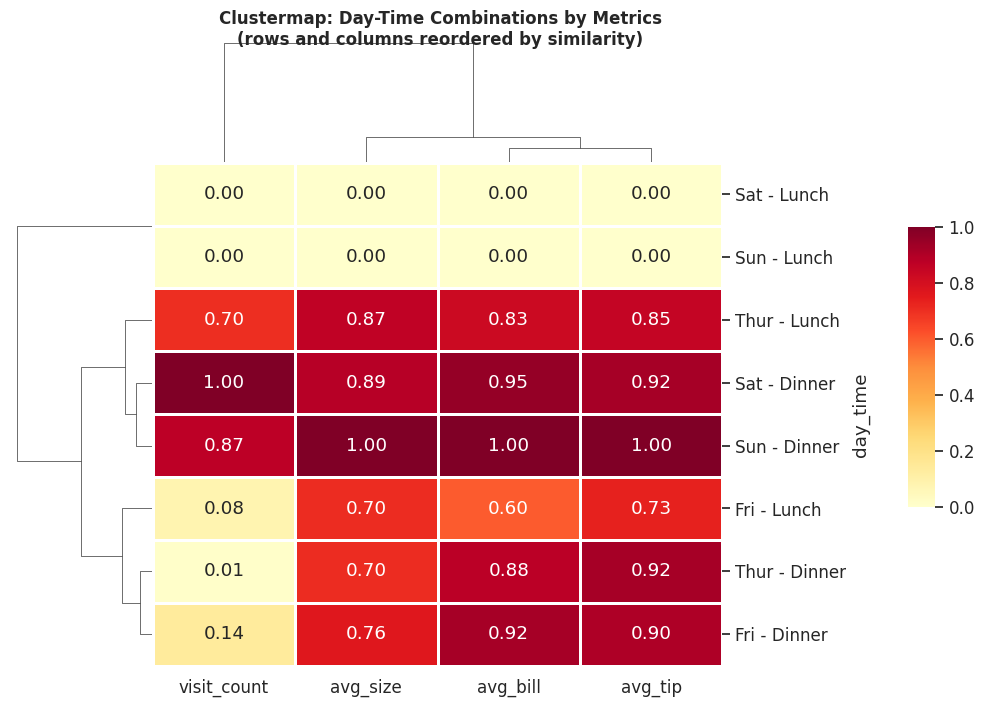

Clustermap saved!
The dendrogram on top shows which columns cluster together.
The dendrogram on left shows which rows are most similar.


In [35]:
cluster_matrix = cluster_matrix.fillna(0) # Fill NaN values with 0
# clustermap is a figure-level function - creates its own figure
# It is NOT called on an ax

# standard_scale=1 normalizes each COLUMN to 0-1 range
# This is important when columns have different scales
# (avg_bill is in tens, visit_count might be in hundreds)
# Without normalization, visit_count would dominate the clustering

g = sns.clustermap(
    cluster_matrix,
    standard_scale=1,    # normalize columns: 0=min, 1=max for each column
    cmap='YlOrRd',
    annot=True,
    fmt='.2f',
    linewidth=0.8,
    linecolor='white',
    figsize=(9, 7),
    cbar_pos=(1.02, 0.3, 0.03, 0.4)  # (left, bottom, width, height) of colorbar
)

g.figure.suptitle('Clustermap: Day-Time Combinations by Metrics\n(rows and columns reordered by similarity)',
                   fontsize=12, fontweight='bold', y=1.01)

plt.savefig('day18_charts/8_clustermap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Clustermap saved!')
print('The dendrogram on top shows which columns cluster together.')
print('The dendrogram on left shows which rows are most similar.')

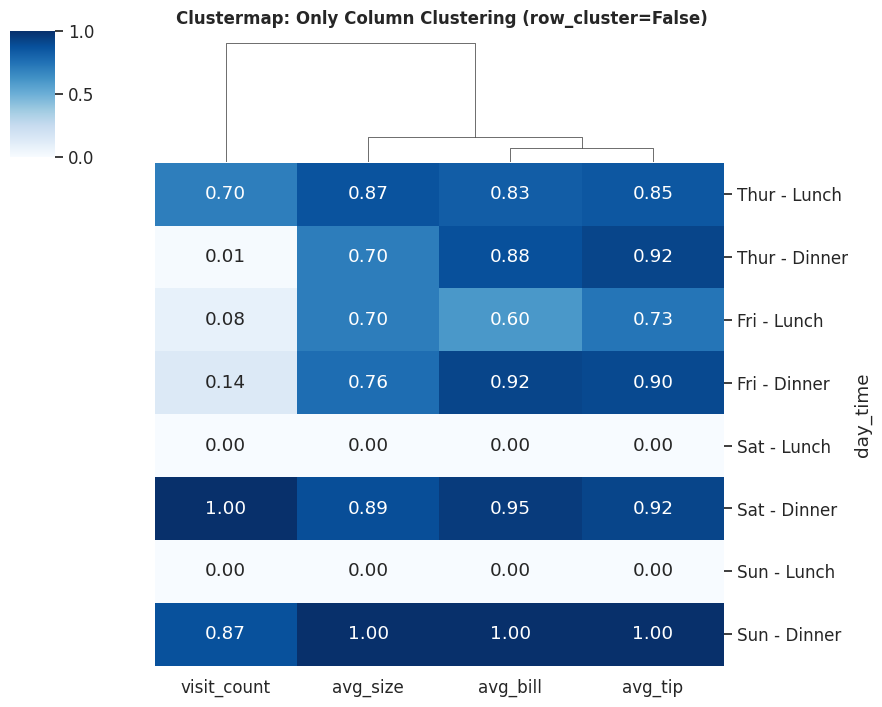

In [36]:
# Clustermap options:
# row_cluster=False  - do not cluster rows (keep original order)
# col_cluster=False  - do not cluster columns
# method='average'   - clustering method: 'single', 'complete', 'average', 'ward'
# metric='euclidean' - distance metric: 'euclidean', 'cosine', 'correlation'
# standard_scale=0   - normalize rows (0) or columns (1)
# z_score=0          - z-score normalize rows (0) or columns (1)

# Clustermap without row clustering (only column clustering)
g2 = sns.clustermap(
    cluster_matrix,
    standard_scale=1,
    cmap='Blues',
    annot=True,
    fmt='.2f',
    row_cluster=False,   # keep rows in original order
    col_cluster=True,    # only cluster columns
    figsize=(9, 7)
)

g2.figure.suptitle('Clustermap: Only Column Clustering (row_cluster=False)',
                    fontsize=12, fontweight='bold', y=1.01)

plt.savefig('day18_charts/8b_clustermap_col_only.png', dpi=150, bbox_inches='tight')
plt.show()

---

# GitHub File: seaborn_part1.py - Complete Code

This is the clean production-ready code to push to GitHub.

Dataset loaded: 244 rows, 7 columns


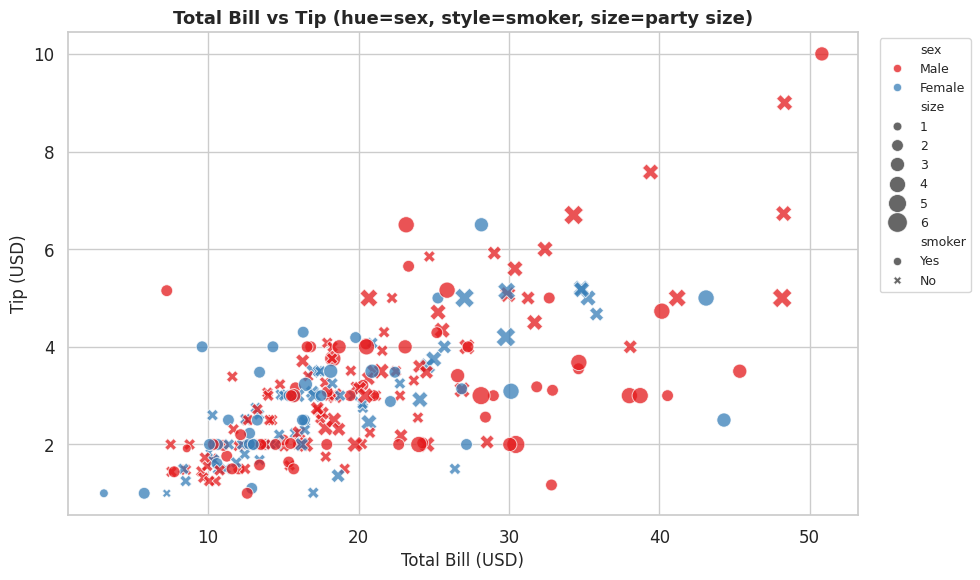

Chart 1: Scatter saved


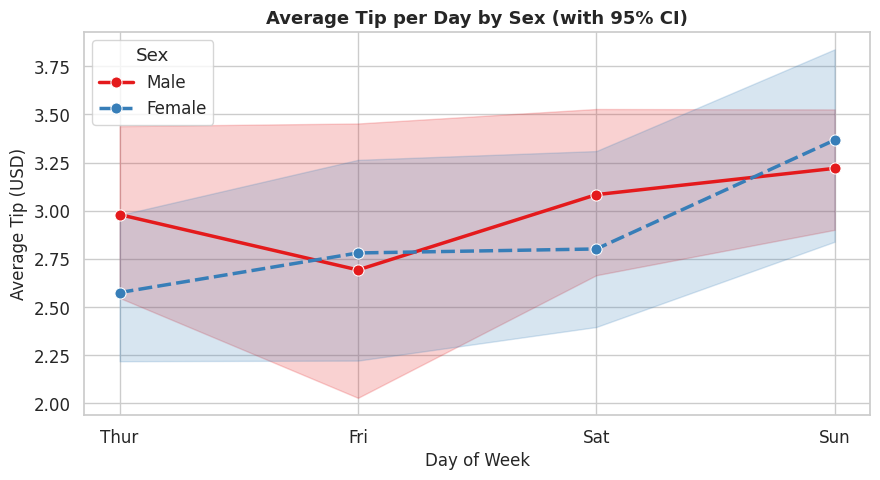

Chart 2: Line plot saved


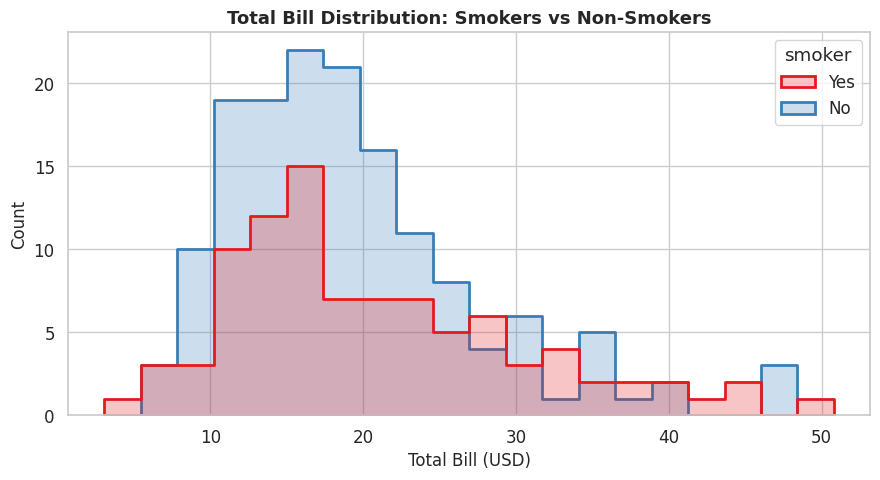

Chart 3: Histogram saved


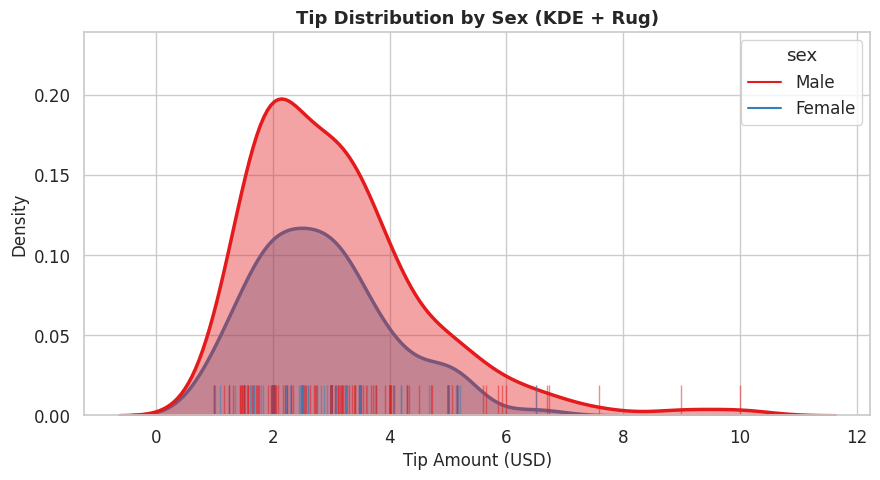

Chart 4: KDE saved


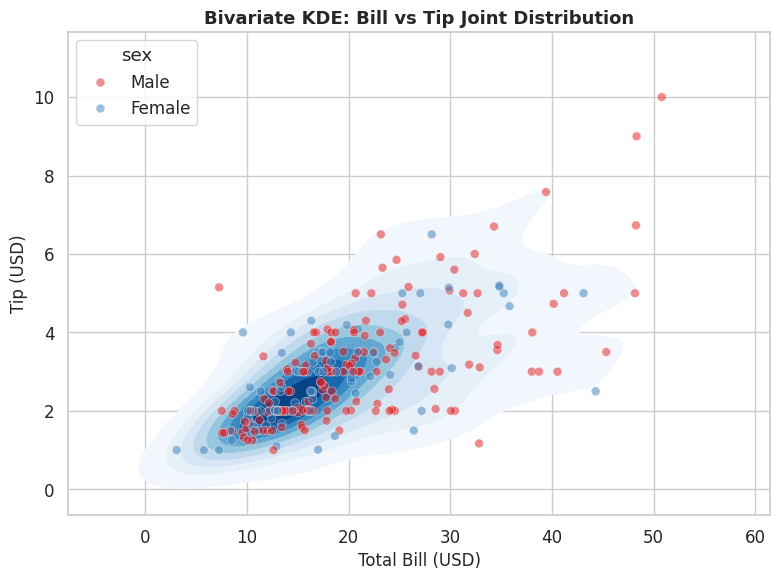

Chart 5: Bivariate KDE saved


/tmp/ipykernel_6567/955525646.py:116: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = tips.pivot_table(index='day', columns='time', values='total_bill', aggfunc='mean')


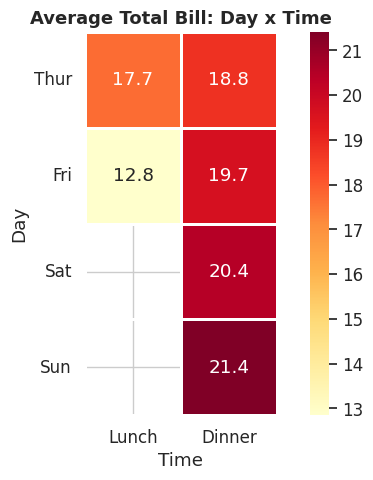

Chart 6: Heatmap saved

All 6 charts saved in day18_charts/


In [38]:
# ============================================================
# day18_seaborn_basics/seaborn_part1.py
# Tips Dataset - 6 Chart Types with Seaborn
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

os.makedirs('day18_charts', exist_ok=True)
sns.set_theme(style='whitegrid', palette='deep', font_scale=1.1)

tips = sns.load_dataset('tips')
print(f'Dataset loaded: {tips.shape[0]} rows, {tips.shape[1]} columns')

# -------------------------------------------------------
# CHART 1: Scatter - total_bill vs tip, hue=sex, size=size
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=tips, x='total_bill', y='tip',
    hue='sex', style='smoker', size='size',
    sizes=(40, 200), alpha=0.75, palette='Set1', ax=ax
)
ax.set_title('Total Bill vs Tip (hue=sex, style=smoker, size=party size)', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Bill (USD)', fontsize=12)
ax.set_ylabel('Tip (USD)', fontsize=12)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('day18_charts/github_1_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 1: Scatter saved')

# -------------------------------------------------------
# CHART 2: Line - day-wise average tip by sex
# -------------------------------------------------------
# Ensure 'day' column is ordered for line plot
day_order = ['Thur', 'Fri', 'Sat', 'Sun']
tips['day'] = pd.Categorical(tips['day'], categories=day_order, ordered=True)

fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(
    data=tips, x='day', y='tip',
    hue='sex', style='sex',
    marker='o', markersize=8, linewidth=2.5,
    # order=['Thur', 'Fri', 'Sat', 'Sun'], # Removed this parameter
    palette='Set1', ax=ax
)
ax.set_title('Average Tip per Day by Sex (with 95% CI)', fontsize=13, fontweight='bold')
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Average Tip (USD)', fontsize=12)
ax.legend(title='Sex')
plt.tight_layout()
plt.savefig('day18_charts/github_2_lineplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 2: Line plot saved')

# -------------------------------------------------------
# CHART 3: Histogram - total_bill distribution, hue=smoker
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(
    data=tips, x='total_bill',
    hue='smoker', bins=20,
    element='step', linewidth=2,
    palette='Set1', ax=ax
)
ax.set_title('Total Bill Distribution: Smokers vs Non-Smokers', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Bill (USD)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
plt.tight_layout()
plt.savefig('day18_charts/github_3_histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 3: Histogram saved')

# -------------------------------------------------------
# CHART 4: KDE - tip distribution, fill=True, hue=sex
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))
sns.kdeplot(
    data=tips, x='tip',
    hue='sex', fill=True,
    alpha=0.4, linewidth=2.5,
    palette='Set1', ax=ax
)
sns.rugplot(data=tips, x='tip', hue='sex', height=0.08, palette='Set1', alpha=0.5, ax=ax)
ax.set_title('Tip Distribution by Sex (KDE + Rug)', fontsize=13, fontweight='bold')
ax.set_xlabel('Tip Amount (USD)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
plt.tight_layout()
plt.savefig('day18_charts/github_4_kde.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 4: KDE saved')

# -------------------------------------------------------
# CHART 5: Bivariate KDE - total_bill vs tip
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))
sns.kdeplot(data=tips, x='total_bill', y='tip',
            fill=True, cmap='Blues', levels=10, thresh=0.05, ax=ax)
sns.scatterplot(data=tips, x='total_bill', y='tip',
                hue='sex', alpha=0.5, s=40, palette='Set1', ax=ax)
ax.set_title('Bivariate KDE: Bill vs Tip Joint Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Bill (USD)', fontsize=12)
ax.set_ylabel('Tip (USD)', fontsize=12)
plt.tight_layout()
plt.savefig('day18_charts/github_5_bivariate_kde.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 5: Bivariate KDE saved')

# -------------------------------------------------------
# CHART 6: Heatmap - pivot: day x time x avg total_bill
# -------------------------------------------------------
pivot = tips.pivot_table(index='day', columns='time', values='total_bill', aggfunc='mean')
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    pivot, annot=True, fmt='.1f',
    cmap='YlOrRd', linewidth=0.8,
    linecolor='white', square=True, ax=ax
)
ax.set_title('Average Total Bill: Day x Time', fontsize=13, fontweight='bold')
ax.set_xlabel('Time')
ax.set_ylabel('Day')
plt.setp(ax.get_xticklabels(), rotation=0)
plt.setp(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.savefig('day18_charts/github_6_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 6: Heatmap saved')

print('\nAll 6 charts saved in day18_charts/')


---

# Complete Reference: Day 18 Cheat Sheet

---

## Figure-level vs Axis-level: The Rule

```
Axis-level functions:              Figure-level functions:
sns.scatterplot()                  sns.relplot(kind='scatter')
sns.lineplot()                     sns.relplot(kind='line')
sns.histplot()                     sns.displot(kind='hist')
sns.kdeplot()                      sns.displot(kind='kde')
sns.boxplot()                      sns.catplot(kind='box')
sns.violinplot()                   sns.catplot(kind='violin')
sns.barplot()                      sns.catplot(kind='bar')

Returns: Matplotlib axes object    Returns: FacetGrid object
Use inside: plt.subplots()         Use standalone: creates own figure
Size control: plt.figure(figsize)  Size control: height=, aspect=
Faceting: manual loop              Faceting: col=, row=, col_wrap=
```

---

## Encoding Variables in Scatter

```python
sns.scatterplot(data=df, x='col1', y='col2',
    hue='col3',         # color by col3
    style='col4',       # shape by col4
    size='col5',        # size by col5
    sizes=(20, 200),    # map size range
    alpha=0.7,
    palette='Set1'
)
```

---

## Faceting with relplot / displot

```python
sns.relplot(data=df, x=, y=, hue=,
    col='col_to_split',     # creates multiple columns
    row='row_to_split',     # creates multiple rows
    col_wrap=2,             # max 2 per row, then wrap
    height=5,               # height per subplot
    aspect=1.2              # width = height * aspect
)
g.set_axis_labels('x label', 'y label')
g.set_titles(col_template='{col_name}')
g.figure.suptitle('Overall Title')
```

---

## Histogram Options

```python
sns.histplot(data=df, x='col', bins=20,
    hue='cat_col',
    multiple='layer',    # layer | dodge | stack | fill
    element='bars',      # bars | step | poly
    stat='count',        # count | density | probability | percent
    kde=True             # overlay KDE curve
)
```

---

## KDE Options

```python
sns.kdeplot(data=df, x='col',
    hue='cat_col',
    fill=True,           # shade under curve
    alpha=0.4,
    bw_adjust=1.0,       # smoothing bandwidth
    common_norm=False    # normalize each group independently
)

# 2D KDE:
sns.kdeplot(data=df, x='col1', y='col2',
    fill=True, cmap='Blues',
    levels=10, thresh=0.05
)
```

---

## Rug Plot

```python
sns.rugplot(data=df, x='col',
    hue='cat_col',
    height=0.08,         # tick height as fraction of axes
    alpha=0.5
)
```

---

## Heatmap

```python
pivot = df.pivot_table(index='r', columns='c', values='v', aggfunc='mean')

sns.heatmap(pivot,
    annot=True,
    fmt='.1f',           # format: '.1f' decimal, 'd' integer, '.2%' percent
    cmap='YlOrRd',
    linewidth=0.8,
    linecolor='white',
    vmin=0, vmax=100,
    center=0,            # for diverging colormaps
    square=True
)
```

---

## Clustermap

```python
sns.clustermap(matrix_df,
    standard_scale=1,    # normalize by column (0=row, 1=col)
    z_score=None,        # z-score normalize
    cmap='YlOrRd',
    annot=True,
    fmt='.2f',
    row_cluster=True,    # cluster rows?
    col_cluster=True,    # cluster columns?
    method='average',    # linkage method
    metric='euclidean',  # distance metric
    figsize=(10, 8)
)
# Returns a ClusterGrid, not FacetGrid or axes
```

---

## Key Differences to Remember

```
plt.hist()            vs  sns.histplot()    - sns has hue, element, stat, kde built-in
ax.imshow()           vs  sns.heatmap()     - sns reads DataFrame labels automatically
plt.plot(kind='line') vs  sns.lineplot()    - sns auto-aggregates with confidence intervals
plt.scatter()         vs  sns.scatterplot() - sns has hue, style, size in one line
```

---
